In [ ]:
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

# =====================================
# LSTM MODEL
# =====================================
try:
    df2018 = pd.read_excel("../data/2018.xlsx")
    df2019 = pd.read_excel("../data/2019.xlsx")
    df2020 = pd.read_excel("../data/2020.xlsx")
    df2021 = pd.read_excel("../data/2021.xlsx")
    df2022 = pd.read_excel("../data/2022.xlsx")
except FileNotFoundError as exc:
    raise FileNotFoundError("Place the Excel files in the current working directory.") from exc


# =====================================================
# PREPROCESS
# =====================================================


def preprocess(df):
    df = df[["time", "sst"]].copy()
    df["time"] = pd.to_datetime(df["time"])
    df["month"] = df["time"].dt.month
    df["day"] = df["time"].dt.day
    df["hour"] = df["time"].dt.hour
    df["dayofyear"] = df["time"].dt.dayofyear

    df["sst_lag1"] = df["sst"].shift(1)
    df["sst_lag8"] = df["sst"].shift(8)
    df["sst_lag24"] = df["sst"].shift(24)

    df = df.dropna().reset_index(drop=True)
    return df


# =====================================================
# BUILD TASKS
# =====================================================


df2018 = preprocess(df2018)
df2019 = preprocess(df2019)
df2020 = preprocess(df2020)
df2021 = preprocess(df2021)
df2022 = preprocess(df2022)

class LSTMModel(nn.Module):

    def __init__(self):

        super().__init__()

        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=64,
            num_layers=2,
            batch_first=True
        )

        self.fc = nn.Linear(64, 1)

    def forward(self, x):

        out, (hn, cn) = self.lstm(x)

        out = self.fc(
            out[:, -1, :]
        )

        return out


# =====================================
# CREATE SEQUENCES
# =====================================

def create_sequences(data, seq_len=24):

    X = []
    y = []

    values = data["sst"].values

    for i in range(len(values) - seq_len):

        X.append(
            values[i:i + seq_len]
        )

        y.append(
            values[i + seq_len]
        )

    return np.array(X), np.array(y)


# =====================================
# BUILD DATASET
# =====================================

X, y = create_sequences(
    df2018,
    seq_len=168
)

split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]


# =====================================
# SCALE DATA
# =====================================

x_scaler = StandardScaler()

X_train = x_scaler.fit_transform(
    X_train.reshape(-1, 1)
).reshape(X_train.shape)

X_test = x_scaler.transform(
    X_test.reshape(-1, 1)
).reshape(X_test.shape)

y_scaler = StandardScaler()

y_train_scaled = y_scaler.fit_transform(
    y_train.reshape(-1, 1)
)

# =====================================
# TENSORS
# =====================================

X_train = torch.tensor(
    X_train,
    dtype=torch.float32
).unsqueeze(-1)

X_test = torch.tensor(
    X_test,
    dtype=torch.float32
).unsqueeze(-1)

y_train_scaled = torch.tensor(
    y_train_scaled,
    dtype=torch.float32
)

# =====================================
# DEVICE
# =====================================

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Using Device:", device)

# =====================================
# MODEL
# =====================================

model = LSTMModel().to(device)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

X_train = X_train.to(device)
y_train_scaled = y_train_scaled.to(device)

# =====================================
# TRAINING
# =====================================

epochs = 300

for epoch in range(epochs):

    model.train()

    optimizer.zero_grad()

    preds = model(X_train)

    loss = criterion(
        preds,
        y_train_scaled
    )

    loss.backward()

    optimizer.step()

    if epoch % 50 == 0:

        print(
            f"Epoch {epoch} Loss:",
            round(loss.item(), 6)
        )

# =====================================
# EVALUATION
# =====================================

model.eval()

X_test = X_test.to(device)

with torch.no_grad():

    preds_scaled = model(
        X_test
    ).cpu().numpy()

preds = y_scaler.inverse_transform(
    preds_scaled
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        preds
    )
)

r2 = r2_score(
    y_test,
    preds
)

print("\nRMSE:", round(rmse, 4))
print("R²:", round(r2, 4))

Using Device: cpu
Epoch 0 Loss: 1.006599
Epoch 50 Loss: 0.031823
Epoch 100 Loss: 0.020509
Epoch 150 Loss: 0.018945
Epoch 200 Loss: 0.017602
Epoch 250 Loss: 0.016328

RMSE: 0.0755
R²: 0.8983


Using device: cpu

  TASK: 2018  (2018.xlsx)
  Total sequences: 2896
  Train: 2316  |  Test: 580
  No replay buffer yet — training on current task only.

  Training for 300 epochs …
  Epoch [  1/300]  Loss: 0.463969
  Epoch [ 50/300]  Loss: 0.005683
  Epoch [100/300]  Loss: 0.005376
  Epoch [150/300]  Loss: 0.005569
  Epoch [200/300]  Loss: 0.005339
  Epoch [250/300]  Loss: 0.005162
  Epoch [300/300]  Loss: 0.005001

  ── Metrics for Task 2018 ──
  RMSE          : 0.0477 °C
  MAE           : 0.0173 °C
  R²            : 0.9592
  Training time : 183.24 s

  Replay buffer updated — total stored samples: 500
  TASK: 2019  (2019.xlsx)
  Total sequences: 2896
  Train: 2316  |  Test: 580
  Training size after replay mix: 2816

  Training for 300 epochs …
  Epoch [  1/300]  Loss: 0.008368
  Epoch [ 50/300]  Loss: 0.007511
  Epoch [100/300]  Loss: 0.007051
  Epoch [150/300]  Loss: 0.006891
  Epoch [200/300]  Loss: 0.006072
  Epoch [250/300]  Loss: 0.005903
  Epoch [300/300]  Loss: 0.005240

  ─

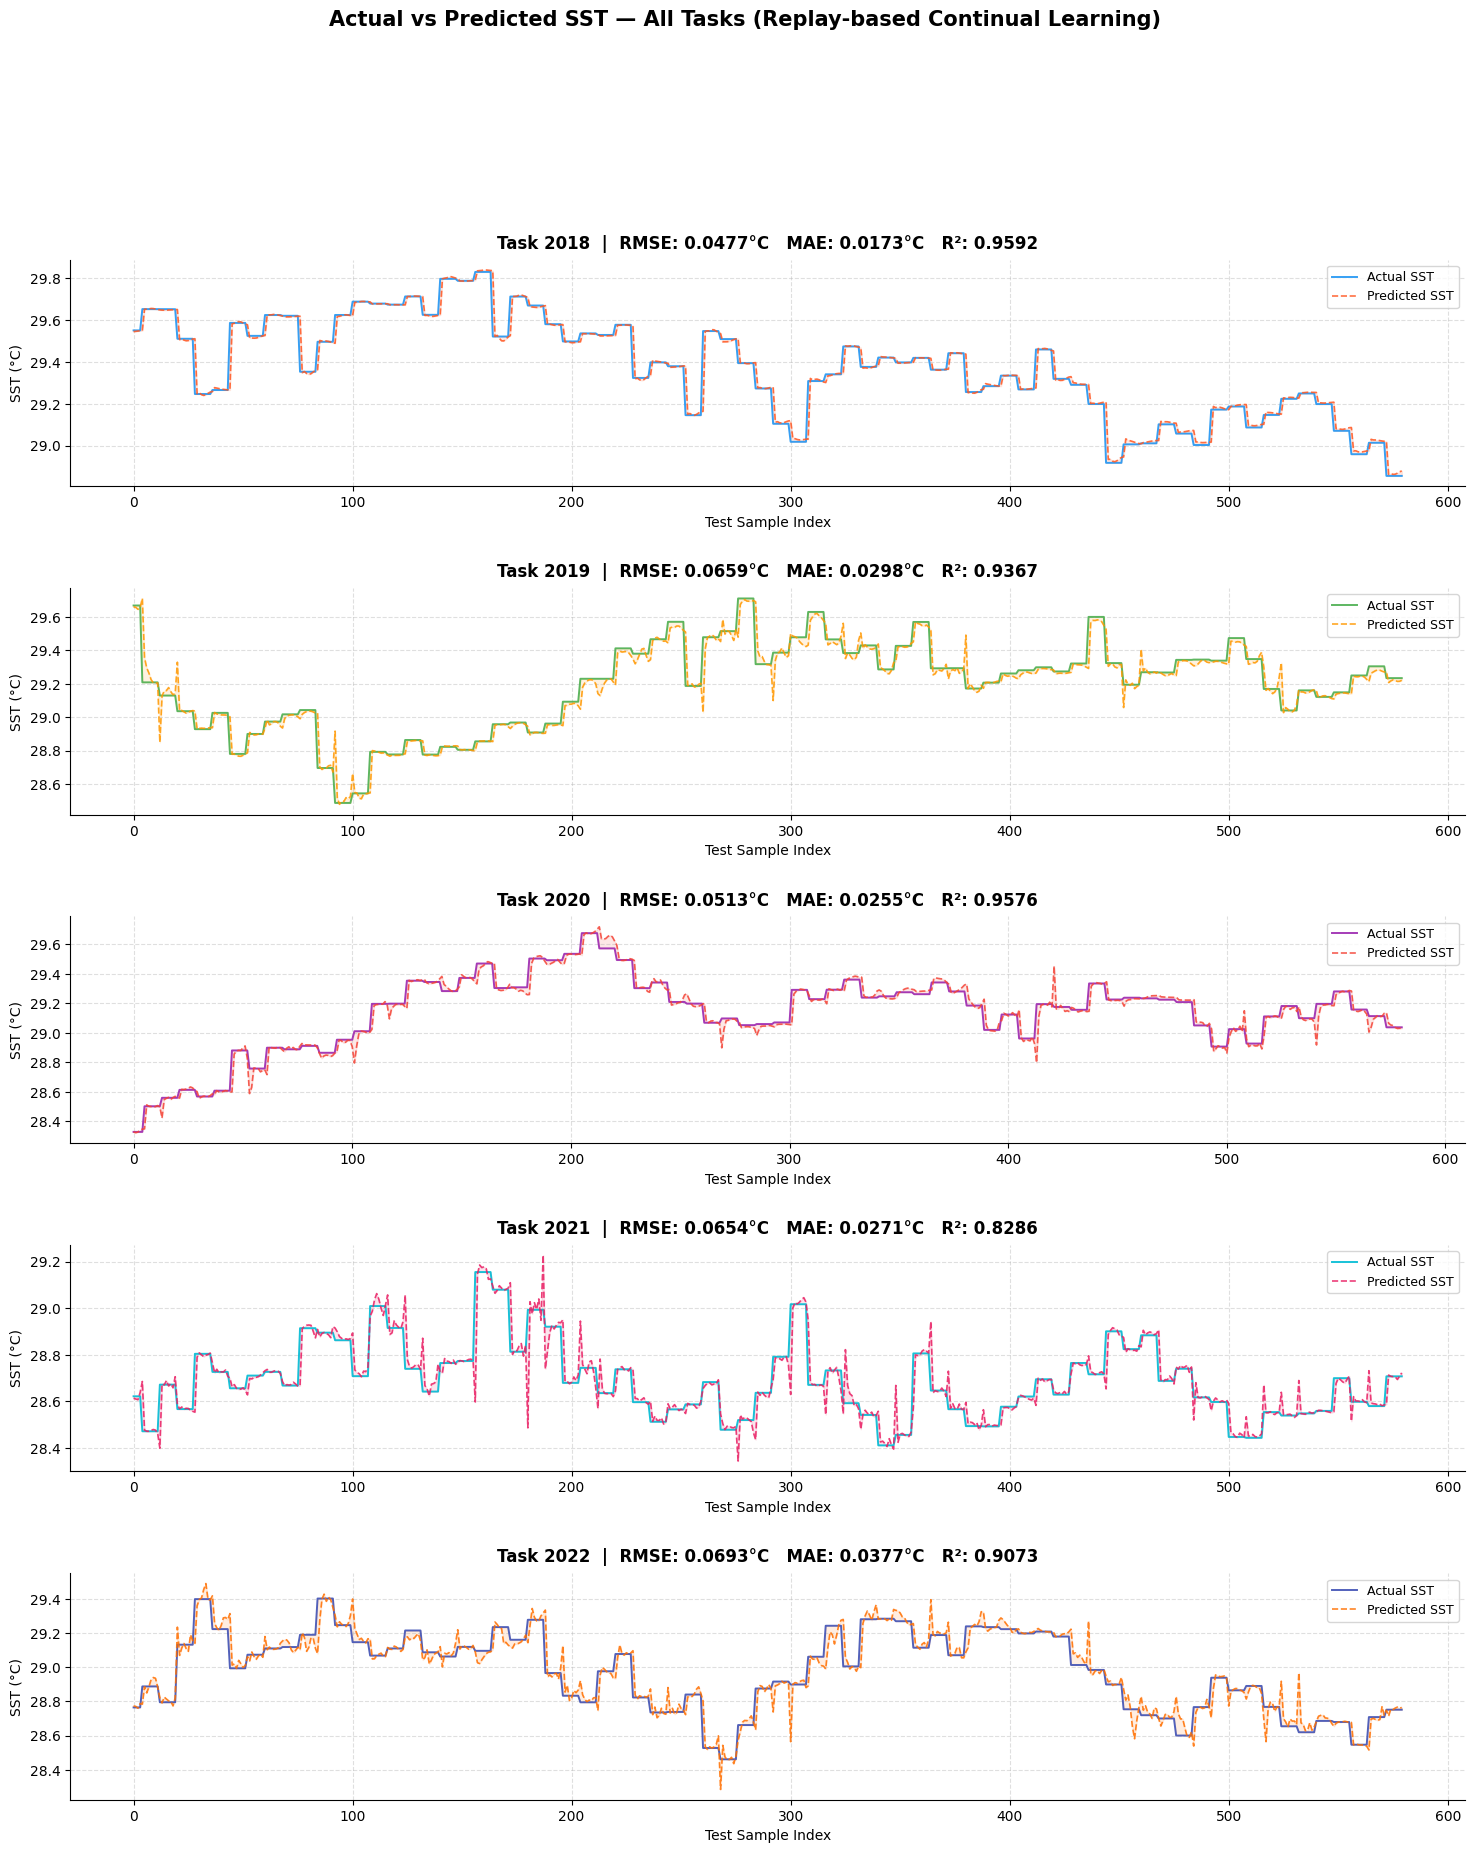

Saved → actual_vs_predicted.png


In [12]:


import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ─────────────────────────────────────────────
# 0. CONFIGURATION
# ─────────────────────────────────────────────
TASK_FILES = {
    2018: "2018.xlsx",
    2019: "2019.xlsx",
    2020: "2020.xlsx",
    2021: "2021.xlsx",
    2022: "2022.xlsx",
}
SEQ_LEN     = 24        # 24 samples × 3 h = 72 h look-back window
TRAIN_RATIO = 0.80
BUFFER_SIZE = 500       # maximum replay samples kept from each past task
EPOCHS      = 300
LR          = 0.001
BATCH_SIZE  = 64
INPUT_SIZE  = 1
HIDDEN_SIZE = 64
NUM_LAYERS  = 2

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}\n")


# ─────────────────────────────────────────────
# 1. LSTM MODEL
# ─────────────────────────────────────────────
class SSTLSTMModel(nn.Module):
    """
    Two-layer LSTM followed by a single fully-connected output layer.
    The last hidden state of the final LSTM layer is used for prediction.
    """
    def __init__(self, input_size: int, hidden_size: int, num_layers: int):
        super(SSTLSTMModel, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (batch, seq_len, input_size)
        lstm_out, (h_n, _) = self.lstm(x)
        # h_n: (num_layers, batch, hidden_size) — take the last layer
        last_hidden = h_n[-1]           # (batch, hidden_size)
        out = self.fc(last_hidden)      # (batch, 1)
        return out


# ─────────────────────────────────────────────
# 2. DATA LOADING & PREPROCESSING
# ─────────────────────────────────────────────
def load_and_preprocess(filepath: str) -> pd.Series:
    """
    Load an Excel file, keep only 'time' and 'sst', parse dates,
    sort by time, and return the SST series.
    """
    df = pd.read_excel(filepath, usecols=["time", "sst"])
    df["time"] = pd.to_datetime(df["time"])
    df = df.sort_values("time").reset_index(drop=True)
    return df["sst"]


def create_sequences(sst_values: np.ndarray, seq_len: int):
    """
    Build (X, y) pairs from a 1-D SST array.
    X[i] = sst_values[i : i+seq_len]   shape (seq_len,)
    y[i] = sst_values[i+seq_len]        scalar
    """
    X, y = [], []
    for i in range(len(sst_values) - seq_len):
        X.append(sst_values[i : i + seq_len])
        y.append(sst_values[i + seq_len])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


def scale_data(X_train, y_train, X_test, y_test):
    """
    Fit StandardScaler on training data only (no test leakage).
    Returns scaled arrays and the fitted scalers.
    X shape: (n_samples, seq_len) → flattened for scaler, then reshaped back.
    y shape: (n_samples,)         → reshaped to (n_samples, 1) for scaler.
    """
    n_train, seq_len = X_train.shape

    # Scaler for input sequences
    scaler_X = StandardScaler()
    X_train_flat = X_train.reshape(-1, 1)          # (n_train * seq_len, 1)
    scaler_X.fit(X_train_flat)
    X_train_scaled = scaler_X.transform(X_train_flat).reshape(n_train, seq_len)
    X_test_scaled  = scaler_X.transform(X_test.reshape(-1, 1)).reshape(X_test.shape[0], seq_len)

    # Scaler for targets
    scaler_y = StandardScaler()
    y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()
    y_test_scaled  = scaler_y.transform(y_test.reshape(-1, 1)).ravel()

    return X_train_scaled, y_train_scaled, X_test_scaled, y_test_scaled, scaler_X, scaler_y


# ─────────────────────────────────────────────
# 3. REPLAY BUFFER
# ─────────────────────────────────────────────
class ReplayBuffer:
    """
    Stores a random subset (up to buffer_size) of each completed task's
    scaled training data to prevent catastrophic forgetting.
    """
    def __init__(self, buffer_size: int):
        self.buffer_size = buffer_size
        self.replay_X: np.ndarray | None = None  # (n_replay, seq_len)
        self.replay_y: np.ndarray | None = None  # (n_replay,)

    def update(self, X_train: np.ndarray, y_train: np.ndarray):
        """
        Randomly sample up to buffer_size examples from the current task
        and append them to the existing buffer.
        """
        n = len(X_train)
        idx = np.random.choice(n, size=min(self.buffer_size, n), replace=False)
        new_X = X_train[idx]
        new_y = y_train[idx]

        if self.replay_X is None:
            self.replay_X = new_X
            self.replay_y = new_y
        else:
            self.replay_X = np.concatenate([self.replay_X, new_X], axis=0)
            self.replay_y = np.concatenate([self.replay_y, new_y], axis=0)

    def mix(self, X_train: np.ndarray, y_train: np.ndarray):
        """
        Return the current task data merged with all replay samples.
        If the buffer is empty, returns the original data unchanged.
        """
        if self.replay_X is None or len(self.replay_X) == 0:
            return X_train, y_train
        X_mixed = np.concatenate([X_train, self.replay_X], axis=0)
        y_mixed = np.concatenate([y_train, self.replay_y], axis=0)
        return X_mixed, y_mixed

    def is_empty(self) -> bool:
        return self.replay_X is None or len(self.replay_X) == 0


# ─────────────────────────────────────────────
# 4. TRAINING
# ─────────────────────────────────────────────
def train_model(
    model: SSTLSTMModel,
    X_train: np.ndarray,
    y_train: np.ndarray,
    epochs: int,
    lr: float,
    batch_size: int,
    device: torch.device,
) -> float:
    """
    Train the LSTM model on (X_train, y_train).
    Returns elapsed wall-clock time in seconds.
    """
    # Convert to tensors and add feature dimension: (n, seq_len) → (n, seq_len, 1)
    X_tensor = torch.tensor(X_train, dtype=torch.float32).unsqueeze(-1).to(device)
    y_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(-1).to(device)

    dataset    = TensorDataset(X_tensor, y_tensor)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    optimizer  = torch.optim.Adam(model.parameters(), lr=lr)
    criterion  = nn.MSELoss()

    model.train()
    start = time.time()

    for epoch in range(1, epochs + 1):
        epoch_loss = 0.0
        for X_batch, y_batch in dataloader:
            optimizer.zero_grad()
            preds = model(X_batch)              # (batch, 1)
            loss  = criterion(preds, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(X_batch)
        epoch_loss /= len(dataset)

        if epoch % 50 == 0 or epoch == 1:
            print(f"  Epoch [{epoch:>3}/{epochs}]  Loss: {epoch_loss:.6f}")

    elapsed = time.time() - start
    return elapsed


# ─────────────────────────────────────────────
# 5. EVALUATION
# ─────────────────────────────────────────────
def evaluate_model(
    model,
    X_test,
    y_test_scaled,
    scaler_y,
    device,
):
    """
    Run inference on the test set, inverse-transform predictions and targets,
    and compute RMSE, MAE, R².
    """

    model.eval()

    X_tensor = torch.tensor(
        X_test,
        dtype=torch.float32
    ).unsqueeze(-1).to(device)

    with torch.no_grad():
        preds_scaled = model(X_tensor).cpu().numpy()

    # Convert back to original SST values
    preds_orig = scaler_y.inverse_transform(
        preds_scaled
    ).ravel()

    y_orig = scaler_y.inverse_transform(
        y_test_scaled.reshape(-1, 1)
    ).ravel()

    # Calculate metrics
    rmse = np.sqrt(
        mean_squared_error(y_orig, preds_orig)
    )

    mae = mean_absolute_error(
        y_orig,
        preds_orig
    )

    r2 = r2_score(
        y_orig,
        preds_orig
    )

    return rmse, mae, r2, y_orig, preds_orig


# ─────────────────────────────────────────────
# 6. MAIN — CONTINUAL LEARNING LOOP
# ─────────────────────────────────────────────
def main():
    # Initialise model, replay buffer, and metric accumulators
    model         = SSTLSTMModel(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS).to(DEVICE)
    replay_buffer = ReplayBuffer(BUFFER_SIZE)

    task_results = {}
    all_rmse, all_mae, all_r2, all_times = [], [], [], []

    for year, filepath in TASK_FILES.items():
        print("=" * 60)
        print(f"  TASK: {year}  ({filepath})")
        print("=" * 60)

        # load & sequence
        sst_series = load_and_preprocess(filepath)
        sst_values = sst_series.values.astype(np.float32)
        X, y = create_sequences(sst_values, SEQ_LEN)
        print(f"  Total sequences: {len(X)}")

        # train/test split
        split      = int(len(X) * TRAIN_RATIO)
        X_train    = X[:split];    y_train = y[:split]
        X_test_raw = X[split:];    y_test_raw = y[split:]
        print(f"  Train: {len(X_train)}  |  Test: {len(X_test_raw)}")

        # scale
        X_tr, y_tr, X_te, y_te, scaler_X, scaler_y = scale_data(
            X_train, y_train, X_test_raw, y_test_raw
        )

        # mix with replay
        if not replay_buffer.is_empty():
            X_tr_mixed, y_tr_mixed = replay_buffer.mix(X_tr, y_tr)
            print(f"  Training size after replay mix: {len(X_tr_mixed)}")
        else:
            X_tr_mixed, y_tr_mixed = X_tr, y_tr
            print(f"  No replay buffer yet — training on current task only.")

        # train
        print(f"\n  Training for {EPOCHS} epochs …")
        elapsed = train_model(
            model, X_tr_mixed, y_tr_mixed,
            EPOCHS, LR, BATCH_SIZE, DEVICE
        )

        # evaluate
        rmse, mae, r2, y_orig_eval, preds_orig_eval = evaluate_model(
            model, X_te, y_te, scaler_y, DEVICE
        )

        # store for plotting
        task_results[year] = {
            "y_true": y_orig_eval,
            "y_pred": preds_orig_eval
        }

        print(f"\n  ── Metrics for Task {year} ──")
        print(f"  RMSE          : {rmse:.4f} °C")
        print(f"  MAE           : {mae:.4f} °C")
        print(f"  R²            : {r2:.4f}")
        print(f"  Training time : {elapsed:.2f} s\n")

        all_rmse.append(rmse)
        all_mae.append(mae)
        all_r2.append(r2)
        all_times.append(elapsed)

        # update replay buffer
        replay_buffer.update(X_tr, y_tr)
        print(f"  Replay buffer updated — total stored samples: {len(replay_buffer.replay_X)}")

    # ── final summary ──────────────────────────────────────────
    print("\n" + "=" * 60)
    print("  FINAL SUMMARY ACROSS ALL TASKS")
    print("=" * 60)
    print(f"  Average RMSE        : {np.mean(all_rmse):.4f} °C")
    print(f"  Average MAE         : {np.mean(all_mae):.4f} °C")
    print(f"  Average R²          : {np.mean(all_r2):.4f}")
    print(f"  Total Training Time : {sum(all_times):.2f} s")
    print("=" * 60)

    # ── return everything needed by plot cells ──────────────────
    return model, task_results, scaler_y, X_te, y_te  # ✅ added


if __name__ == "__main__":
    model, task_results, scaler_y, X_te, y_te = main()  # ✅ capture all returned values

# ─────────────────────────────────────────────────────────────
# CELL 1 — Actual vs Predicted for every yearly task
# ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import torch

fig = plt.figure(figsize=(18, 20))
gs  = gridspec.GridSpec(5, 1, hspace=0.45)

colors = {
    2018: ("#2196F3", "#FF5722"),
    2019: ("#4CAF50", "#FF9800"),
    2020: ("#9C27B0", "#F44336"),
    2021: ("#00BCD4", "#E91E63"),
    2022: ("#3F51B5", "#FF6F00"),
}

for i, (year, data) in enumerate(task_results.items()):
    ax = fig.add_subplot(gs[i])

    y_true = data["y_true"]
    y_pred = data["y_pred"]
    x_axis = np.arange(len(y_true))

    ax.plot(x_axis, y_true, color=colors[year][0],
            linewidth=1.4, label="Actual SST", alpha=0.9)
    ax.plot(x_axis, y_pred, color=colors[year][1],
            linewidth=1.2, label="Predicted SST",
            linestyle="--", alpha=0.85)

    # shaded error region
    ax.fill_between(x_axis, y_true, y_pred,
                    alpha=0.12, color=colors[year][1])

    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mae  = np.mean(np.abs(y_true - y_pred))
    r2   = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - np.mean(y_true))**2)

    ax.set_title(
        f"Task {year}  |  RMSE: {rmse:.4f}°C   MAE: {mae:.4f}°C   R²: {r2:.4f}",
        fontsize=12, fontweight="bold", pad=8
    )
    ax.set_xlabel("Test Sample Index", fontsize=10)
    ax.set_ylabel("SST (°C)", fontsize=10)
    ax.legend(loc="upper right", fontsize=9)
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle("Actual vs Predicted SST — All Tasks (Replay-based Continual Learning)",
             fontsize=15, fontweight="bold", y=1.005)
plt.savefig("actual_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → actual_vs_predicted.png")


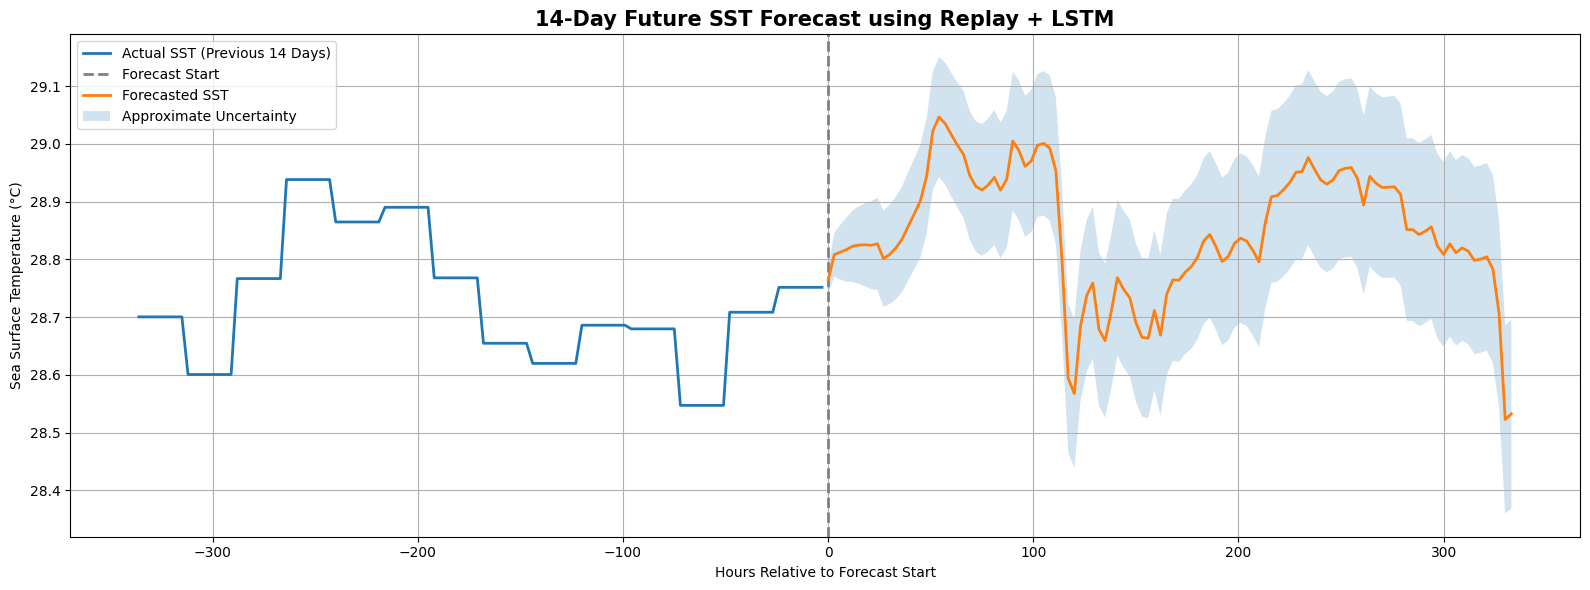

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import torch

# ==========================================================
# CONFIGURATION
# ==========================================================

FORECAST_STEPS = 112      # 112 x 3 hours = 14 days
CONTEXT_STEPS = 112       # show previous 14 days

# Use the RMSE obtained from your final evaluation
# Example:
# rmse = 0.073

# ==========================================================
# START FROM LAST AVAILABLE SEQUENCE
# ==========================================================

seed_window = X_te[-1].copy()

current_window = seed_window.copy()

forecast_scaled = []

model.eval()

# ==========================================================
# RECURSIVE FORECASTING
# ==========================================================

for _ in range(FORECAST_STEPS):

    x_input = torch.tensor(
        current_window.reshape(1, SEQ_LEN, 1),
        dtype=torch.float32
    ).to(DEVICE)

    with torch.no_grad():

        pred_scaled = (
            model(x_input)
            .cpu()
            .numpy()
            .flatten()[0]
        )

    forecast_scaled.append(pred_scaled)

    # Update rolling window

    current_window = np.roll(current_window, -1)
    current_window[-1] = pred_scaled

# ==========================================================
# CONVERT BACK TO ORIGINAL SST
# ==========================================================

forecast_orig = scaler_y.inverse_transform(
    np.array(forecast_scaled).reshape(-1, 1)
).flatten()

# ==========================================================
# LAST ACTUAL OBSERVATIONS
# ==========================================================

actual_scaled = y_te[-CONTEXT_STEPS:]

actual_orig = scaler_y.inverse_transform(
    actual_scaled.reshape(-1, 1)
).flatten()

# ==========================================================
# TIME AXES
# ==========================================================

past_hours = np.arange(
    -CONTEXT_STEPS * 3,
    0,
    3
)

future_hours = np.arange(
    0,
    FORECAST_STEPS * 3,
    3
)

# ==========================================================
# UNCERTAINTY ESTIMATION
# ==========================================================

# Uses model RMSE

growth = 0.5*np.log1p(
    np.arange(1, FORECAST_STEPS + 1)
)

uncertainty = rmse * growth
upper = forecast_orig + uncertainty
lower = forecast_orig - uncertainty

# ==========================================================
# PLOT
# ==========================================================

plt.figure(figsize=(16, 6))

# Actual history

plt.plot(
    past_hours,
    actual_orig,
    linewidth=2,
    label="Actual SST (Previous 14 Days)"
)

# Forecast start

plt.axvline(
    x=0,
    linestyle="--",
    linewidth=2,
    color="gray",
    label="Forecast Start"
)

# Forecast

plt.plot(
    future_hours,
    forecast_orig,
    linewidth=2,
    label="Forecasted SST"
)

# Confidence band

plt.fill_between(
    future_hours,
    lower,
    upper,
    alpha=0.20,
    label="Approximate Uncertainty"
)

# Labels

plt.title(
    "14-Day Future SST Forecast using Replay + LSTM",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Hours Relative to Forecast Start")
plt.ylabel("Sea Surface Temperature (°C)")

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()

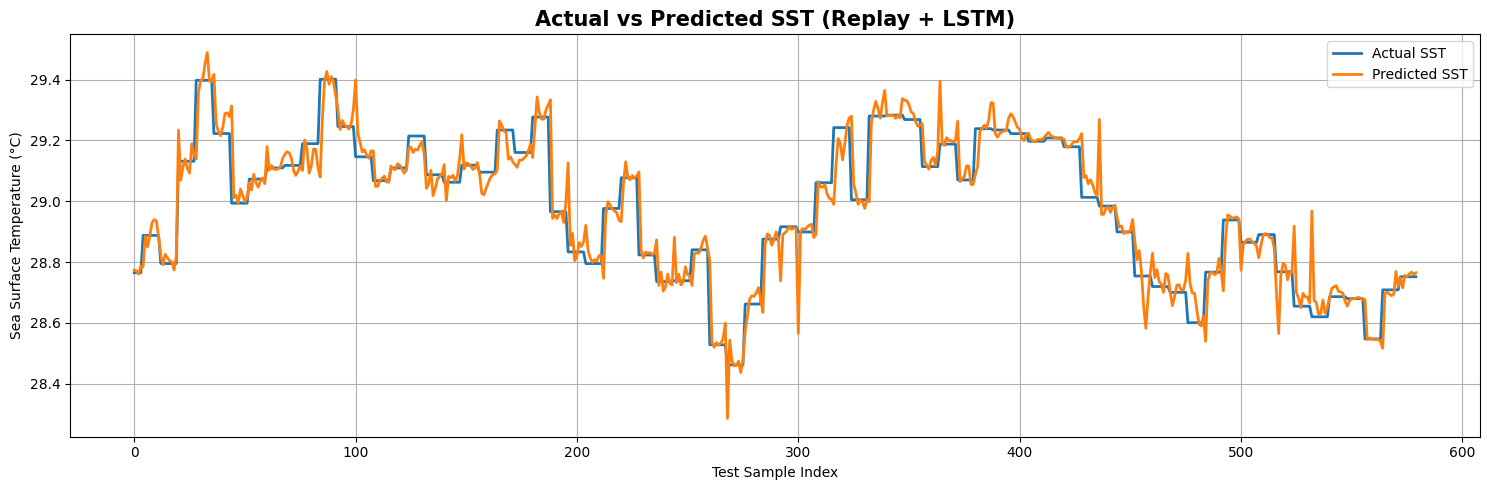

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import torch

# ==========================================
# Predict on the 2022 Test Set
# ==========================================

model.eval()

X_tensor = torch.tensor(
    X_te,
    dtype=torch.float32
).unsqueeze(-1).to(DEVICE)

with torch.no_grad():

    preds_scaled = model(
        X_tensor
    ).cpu().numpy()

# ==========================================
# Convert back to original SST values
# ==========================================

preds = scaler_y.inverse_transform(
    preds_scaled
).flatten()

actual = scaler_y.inverse_transform(
    y_te.reshape(-1, 1)
).flatten()

# ==========================================
# Plot
# ==========================================

plt.figure(figsize=(15, 5))

plt.plot(
    actual,
    linewidth=2,
    label="Actual SST"
)

plt.plot(
    preds,
    linewidth=2,
    label="Predicted SST"
)

plt.title(
    "Actual vs Predicted SST (Replay + LSTM)",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Test Sample Index")
plt.ylabel("Sea Surface Temperature (°C)")

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()

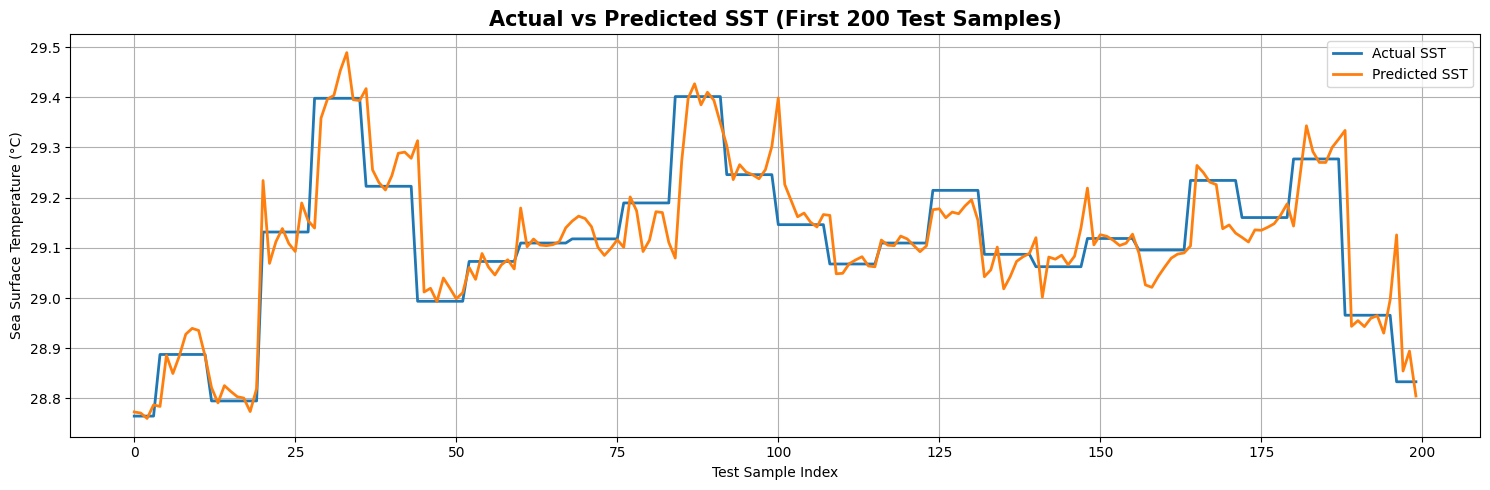

In [18]:
plt.figure(figsize=(15, 5))

plt.plot(
    actual[:200],
    linewidth=2,
    label="Actual SST"
)

plt.plot(
    preds[:200],
    linewidth=2,
    label="Predicted SST"
)

plt.title(
    "Actual vs Predicted SST (First 200 Test Samples)",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Test Sample Index")
plt.ylabel("Sea Surface Temperature (°C)")

plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

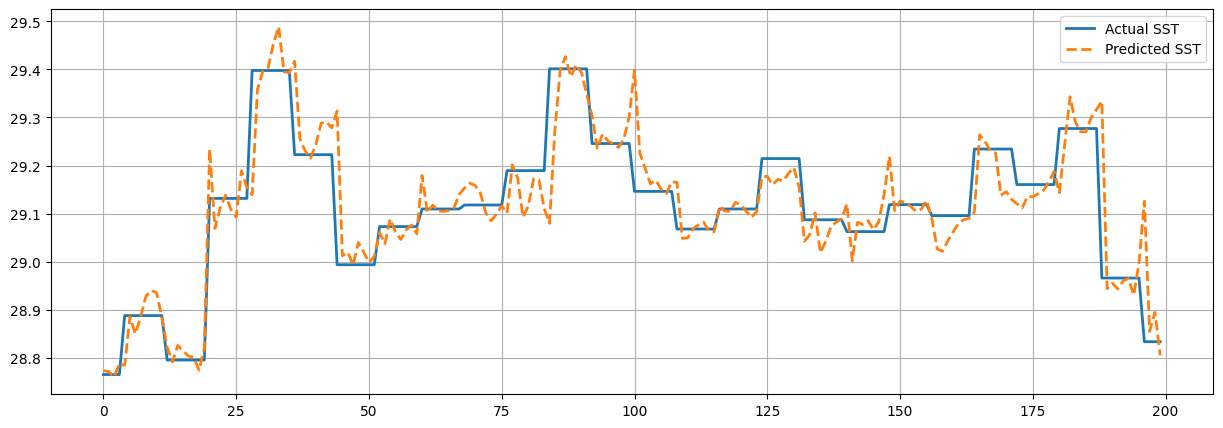

In [19]:
plt.figure(figsize=(15,5))

plt.plot(
    actual[:200],
    label="Actual SST",
    linewidth=2
)

plt.plot(
    preds[:200],
    label="Predicted SST",
    linewidth=2,
    linestyle="--"
)

plt.legend()
plt.grid(True)
plt.show()

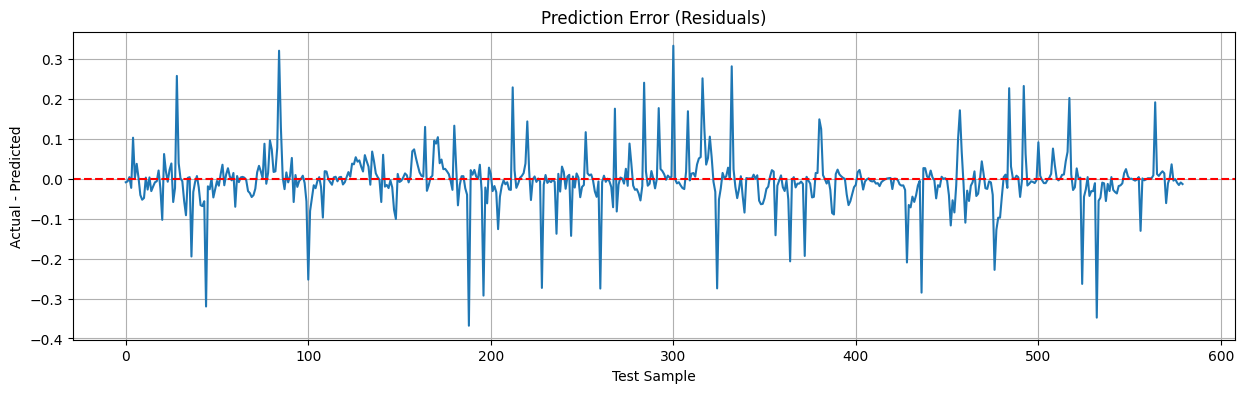

In [20]:
errors = actual - preds

plt.figure(figsize=(15,4))

plt.plot(errors)

plt.axhline(
    0,
    color="red",
    linestyle="--"
)

plt.title("Prediction Error (Residuals)")
plt.xlabel("Test Sample")
plt.ylabel("Actual - Predicted")

plt.grid(True)

plt.show()

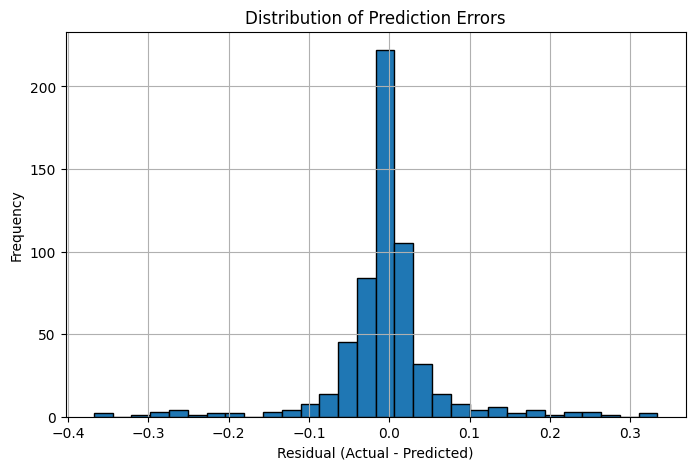

In [21]:
errors = actual - preds

plt.figure(figsize=(8,5))

plt.hist(
    errors,
    bins=30,
    edgecolor="black"
)

plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Frequency")
plt.title("Distribution of Prediction Errors")

plt.grid(True)

plt.show()

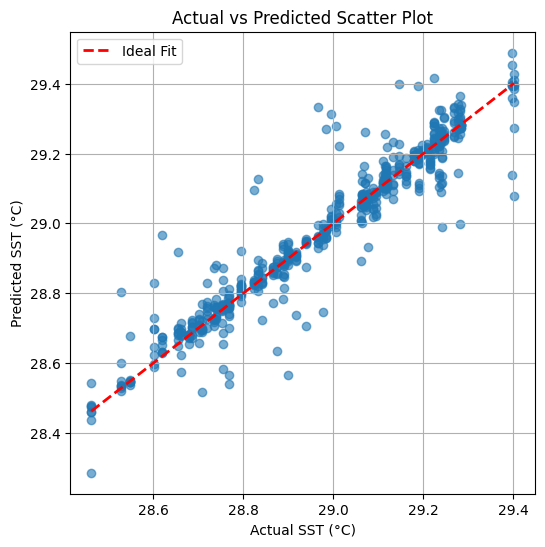

In [22]:
plt.figure(figsize=(6,6))

plt.scatter(actual, preds, alpha=0.6)

# Perfect prediction line
plt.plot(
    [actual.min(), actual.max()],
    [actual.min(), actual.max()],
    "r--",
    linewidth=2,
    label="Ideal Fit"
)

plt.xlabel("Actual SST (°C)")
plt.ylabel("Predicted SST (°C)")
plt.title("Actual vs Predicted Scatter Plot")
plt.legend()
plt.grid(True)

plt.show()

In [1]:
"""
EWC (Elastic Weight Consolidation) + LSTM for SST Prediction
=============================================================
Continual Learning without Replay.
Catastrophic forgetting is prevented by adding a penalty term
to the loss function that protects weights that were important
for previous tasks — identified via the Fisher Information Matrix.

Tasks trained sequentially: 2018 → 2019 → 2020 → 2021 → 2022
"""

import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from copy import deepcopy

# ─────────────────────────────────────────────
# 0. CONFIGURATION
# ─────────────────────────────────────────────
TASK_FILES = {
    2018: "2018.xlsx",
    2019: "2019.xlsx",
    2020: "2020.xlsx",
    2021: "2021.xlsx",
    2022: "2022.xlsx",
}

SEQ_LEN     = 24        # 24 × 3h = 72h look-back window
TRAIN_RATIO = 0.80
EPOCHS      = 300
LR          = 0.001
BATCH_SIZE  = 64
INPUT_SIZE  = 1
HIDDEN_SIZE = 64
NUM_LAYERS  = 2

# ── EWC specific ──────────────────────────────
# How strongly to protect old task weights.
# Higher = less forgetting but slower adaptation to new tasks.
# Lower  = faster adaptation but more forgetting.
EWC_LAMBDA  = 5000

# Number of samples used to estimate the Fisher matrix.
# More samples = more accurate Fisher but slower computation.
FISHER_SAMPLES = 200

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}\n")


# ─────────────────────────────────────────────
# 1. LSTM MODEL
# ─────────────────────────────────────────────
class SSTLSTMModel(nn.Module):
    """
    Two-layer LSTM followed by a single FC output layer.
    Last hidden state of the final LSTM layer → prediction.
    """
    def __init__(self, input_size, hidden_size, num_layers):
        super(SSTLSTMModel, self).__init__()
        self.lstm = nn.LSTM(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            batch_first = True,
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x: (batch, seq_len, 1)
        _, (h_n, _) = self.lstm(x)
        last_hidden  = h_n[-1]          # (batch, hidden_size)
        return self.fc(last_hidden)     # (batch, 1)


# ─────────────────────────────────────────────
# 2. EWC CLASS
# ─────────────────────────────────────────────
class EWC:
    """
    Elastic Weight Consolidation.

    After finishing each task:
      1. Save a snapshot of current weights as the "optimal" point (theta*)
      2. Compute the Fisher Information Matrix diagonal
         (how sensitive the loss is to each weight)

    During the next task:
      3. Add an EWC penalty to the loss:
         penalty = (lambda/2) * sum[ F_i * (theta_i - theta*_i)^2 ]

    This penalises moving weights that were important for old tasks.
    Weights with high Fisher values are "protected" — they can't move much.
    Weights with low Fisher values are "free" — the model adapts them freely.
    """

    def __init__(self):
        # Lists — one entry per completed task
        self.fisher_matrices = []   # list of {param_name: fisher_diagonal}
        self.optimal_weights = []   # list of {param_name: weight_snapshot}

    # ── 2a. Fisher Matrix Computation ────────────────────────────
    def compute_fisher(self, model, X_sample, y_sample, device):
        """
        Estimate the diagonal of the Fisher Information Matrix.

        The Fisher diagonal F_i for weight W_i is:
            F_i = E[ (d log p(y|x) / d W_i)^2 ]

        In practice for regression we approximate this as:
            F_i = mean of squared gradients over a sample of data

        High F_i → this weight strongly affects predictions → protect it
        Low  F_i → this weight barely matters → let it change freely

        Parameters
        ----------
        X_sample : scaled input sequences  (n, seq_len)
        y_sample : scaled targets          (n,)
        """
        model.eval()

        # Initialise Fisher diagonal to zero for every parameter
        fisher = {}
        for name, param in model.named_parameters():
            fisher[name] = torch.zeros_like(param.data)

        criterion = nn.MSELoss()

        # Convert sample data to tensors
        X_t = torch.tensor(
            X_sample, dtype=torch.float32
        ).unsqueeze(-1).to(device)          # (n, seq_len, 1)

        y_t = torch.tensor(
            y_sample, dtype=torch.float32
        ).unsqueeze(-1).to(device)          # (n, 1)

        # Accumulate squared gradients over each sample individually
        for i in range(len(X_t)):
            model.zero_grad()

            x_i = X_t[i].unsqueeze(0)       # (1, seq_len, 1)
            y_i = y_t[i].unsqueeze(0)       # (1, 1)

            pred = model(x_i)
            loss = criterion(pred, y_i)
            loss.backward()

            # Square the gradient and accumulate
            for name, param in model.named_parameters():
                if param.grad is not None:
                    fisher[name] += param.grad.data.clone() ** 2

        # Average over all samples
        for name in fisher:
            fisher[name] /= len(X_t)

        return fisher

    # ── 2b. Register a completed task ────────────────────────────
    def register_task(self, model, X_sample, y_sample, device):
        """
        Called after finishing training on a task.
        Saves:
          - diagonal Fisher matrix (importance of each weight)
          - snapshot of current weights (optimal point for this task)
        """
        print(f"\n  Computing Fisher Information Matrix "
              f"on {len(X_sample)} samples …")

        fisher = self.compute_fisher(model, X_sample, y_sample, device)
        self.fisher_matrices.append(fisher)

        # Deep-copy current weights as the anchor point theta*
        weights = {}
        for name, param in model.named_parameters():
            weights[name] = param.data.clone()
        self.optimal_weights.append(weights)

        print(f"  Fisher Matrix computed. "
              f"Total tasks registered: {len(self.fisher_matrices)}")

    # ── 2c. EWC Penalty ──────────────────────────────────────────
    def penalty(self, model):
        """
        Compute the EWC regularisation penalty across all past tasks.

        penalty = (lambda / 2) * sum_tasks sum_weights [
                      F_i * (current_W_i - optimal_W_i)^2
                  ]

        This is added to the MSE loss during training.
        If no tasks registered yet → penalty = 0 (first task trains freely).
        """
        if len(self.fisher_matrices) == 0:
            return torch.tensor(0.0, device=DEVICE)

        penalty_sum = torch.tensor(0.0, device=DEVICE)

        for fisher, optimal in zip(self.fisher_matrices, self.optimal_weights):
            for name, param in model.named_parameters():
                if name in fisher:
                    # F_i * (W_i - W*_i)^2  summed over all elements
                    f   = fisher[name].to(DEVICE)
                    w   = param
                    w_star = optimal[name].to(DEVICE)

                    penalty_sum += (f * (w - w_star) ** 2).sum()

        return (EWC_LAMBDA / 2) * penalty_sum


# ─────────────────────────────────────────────
# 3. DATA LOADING & PREPROCESSING
# ─────────────────────────────────────────────
def load_and_preprocess(filepath):
    """Load Excel file, keep time + sst, sort chronologically."""
    df = pd.read_excel(filepath, usecols=["time", "sst"])
    df["time"] = pd.to_datetime(df["time"])
    df = df.sort_values("time").reset_index(drop=True)
    return df["sst"]


def create_sequences(sst_values, seq_len):
    """
    Sliding window sequences.
    X[i] = sst[i : i+seq_len]   (24 past readings)
    y[i] = sst[i+seq_len]       (next reading to predict)
    """
    X, y = [], []
    for i in range(len(sst_values) - seq_len):
        X.append(sst_values[i : i + seq_len])
        y.append(sst_values[i + seq_len])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


def scale_data(X_train, y_train, X_test, y_test):
    """
    Fit StandardScaler on training data only (no test leakage).
    Input and target scaled separately.
    """
    n_train, seq_len = X_train.shape

    scaler_X = StandardScaler()
    X_train_scaled = scaler_X.fit_transform(
        X_train.reshape(-1, 1)
    ).reshape(n_train, seq_len)
    X_test_scaled  = scaler_X.transform(
        X_test.reshape(-1, 1)
    ).reshape(X_test.shape[0], seq_len)

    scaler_y = StandardScaler()
    y_train_scaled = scaler_y.fit_transform(
        y_train.reshape(-1, 1)
    ).ravel()
    y_test_scaled  = scaler_y.transform(
        y_test.reshape(-1, 1)
    ).ravel()

    return (X_train_scaled, y_train_scaled,
            X_test_scaled,  y_test_scaled,
            scaler_X, scaler_y)


# ─────────────────────────────────────────────
# 4. TRAINING WITH EWC LOSS
# ─────────────────────────────────────────────
def train_model_ewc(model, ewc, X_train, y_train,
                    epochs, lr, batch_size, device):
    """
    Train LSTM with EWC-augmented loss:

        total_loss = MSE_loss + EWC_penalty

    MSE_loss   → fits the current task
    EWC_penalty → protects important weights from previous tasks

    On the first task, EWC_penalty = 0 so training is identical
    to standard LSTM training.
    """
    X_tensor = torch.tensor(
        X_train, dtype=torch.float32
    ).unsqueeze(-1).to(device)              # (n, seq_len, 1)

    y_tensor = torch.tensor(
        y_train, dtype=torch.float32
    ).unsqueeze(-1).to(device)              # (n, 1)

    dataset    = TensorDataset(X_tensor, y_tensor)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    optimizer  = torch.optim.Adam(model.parameters(), lr=lr)
    mse_loss   = nn.MSELoss()

    model.train()
    start = time.time()

    for epoch in range(1, epochs + 1):
        epoch_total_loss = 0.0
        epoch_mse_loss   = 0.0
        epoch_ewc_loss   = 0.0

        for X_batch, y_batch in dataloader:
            optimizer.zero_grad()

            preds = model(X_batch)

            # ── Core task loss ───────────────────────────────────
            loss_mse = mse_loss(preds, y_batch)

            # ── EWC penalty (0 on first task) ────────────────────
            loss_ewc = ewc.penalty(model)

            # ── Combined loss ────────────────────────────────────
            # This is the KEY difference from standard training:
            # the gradient flows through BOTH terms, so weights
            # important to old tasks resist being changed.
            total_loss = loss_mse + loss_ewc

            total_loss.backward()
            optimizer.step()

            epoch_total_loss += total_loss.item() * len(X_batch)
            epoch_mse_loss   += loss_mse.item()   * len(X_batch)
            epoch_ewc_loss   += loss_ewc.item()   * len(X_batch)

        n = len(dataset)
        epoch_total_loss /= n
        epoch_mse_loss   /= n
        epoch_ewc_loss   /= n

        if epoch % 50 == 0 or epoch == 1:
            print(f"  Epoch [{epoch:>3}/{epochs}]  "
                  f"Total: {epoch_total_loss:.6f}  "
                  f"MSE: {epoch_mse_loss:.6f}  "
                  f"EWC: {epoch_ewc_loss:.6f}")

    return time.time() - start


# ─────────────────────────────────────────────
# 5. EVALUATION
# ─────────────────────────────────────────────
def evaluate_model(model, X_test, y_test_scaled, scaler_y, device):
    """
    Inference → inverse transform → compute RMSE, MAE, R².
    Returns metrics and raw arrays for plotting.
    """
    model.eval()
    X_tensor = torch.tensor(
        X_test, dtype=torch.float32
    ).unsqueeze(-1).to(device)

    with torch.no_grad():
        preds_scaled = model(X_tensor).cpu().numpy()    # (n, 1)

    preds_orig = scaler_y.inverse_transform(preds_scaled).ravel()
    y_orig     = scaler_y.inverse_transform(
        y_test_scaled.reshape(-1, 1)
    ).ravel()

    rmse = np.sqrt(mean_squared_error(y_orig, preds_orig))
    mae  = mean_absolute_error(y_orig, preds_orig)
    r2   = r2_score(y_orig, preds_orig)

    return rmse, mae, r2, y_orig, preds_orig


# ─────────────────────────────────────────────
# 6. MAIN — EWC CONTINUAL LEARNING LOOP
# ─────────────────────────────────────────────
def main():
    model = SSTLSTMModel(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS).to(DEVICE)
    ewc   = EWC()

    task_results                    = {}
    all_rmse, all_mae, all_r2, all_times = [], [], [], []

    for year, filepath in TASK_FILES.items():
        print("=" * 65)
        print(f"  TASK: {year}  ({filepath})")
        print("=" * 65)

        # ── Load & sequence ──────────────────────────────────────
        sst_series = load_and_preprocess(filepath)
        sst_values = sst_series.values.astype(np.float32)
        X, y       = create_sequences(sst_values, SEQ_LEN)
        print(f"  Total sequences : {len(X)}")

        # ── Train/test split ─────────────────────────────────────
        split      = int(len(X) * TRAIN_RATIO)
        X_train    = X[:split];     y_train    = y[:split]
        X_test_raw = X[split:];     y_test_raw = y[split:]
        print(f"  Train: {len(X_train)}  |  Test: {len(X_test_raw)}")

        # ── Scale ────────────────────────────────────────────────
        X_tr, y_tr, X_te, y_te, scaler_X, scaler_y = scale_data(
            X_train, y_train, X_test_raw, y_test_raw
        )

        # ── Train with EWC loss ──────────────────────────────────
        # First task: EWC penalty = 0 → standard MSE training
        # Subsequent tasks: EWC penalty protects old weights
        print(f"\n  Training for {EPOCHS} epochs with EWC …")
        elapsed = train_model_ewc(
            model, ewc, X_tr, y_tr,
            EPOCHS, LR, BATCH_SIZE, DEVICE
        )

        # ── Evaluate ─────────────────────────────────────────────
        rmse, mae, r2, y_orig_eval, preds_orig_eval = evaluate_model(
            model, X_te, y_te, scaler_y, DEVICE
        )

        task_results[year] = {
            "y_true": y_orig_eval,
            "y_pred": preds_orig_eval,
        }

        print(f"\n  ── Metrics for Task {year} ──")
        print(f"  RMSE          : {rmse:.4f} °C")
        print(f"  MAE           : {mae:.4f} °C")
        print(f"  R²            : {r2:.4f}")
        print(f"  Training time : {elapsed:.2f} s\n")

        all_rmse.append(rmse)
        all_mae.append(mae)
        all_r2.append(r2)
        all_times.append(elapsed)

        # ── Register task with EWC ───────────────────────────────
        # Sample FISHER_SAMPLES random training points to estimate Fisher
        idx      = np.random.choice(len(X_tr),
                                    size=min(FISHER_SAMPLES, len(X_tr)),
                                    replace=False)
        ewc.register_task(model, X_tr[idx], y_tr[idx], DEVICE)

    # ── Summary ──────────────────────────────────────────────────
    print("\n" + "=" * 65)
    print("  FINAL SUMMARY ACROSS ALL TASKS")
    print("=" * 65)
    print(f"  Average RMSE        : {np.mean(all_rmse):.4f} °C")
    print(f"  Average MAE         : {np.mean(all_mae):.4f} °C")
    print(f"  Average R²          : {np.mean(all_r2):.4f}")
    print(f"  Total Training Time : {sum(all_times):.2f} s")
    print("=" * 65)

    return model, task_results, scaler_y, X_te, y_te


if __name__ == "__main__":
    model, task_results, scaler_y, X_te, y_te = main()

Using device: cpu

  TASK: 2018  (2018.xlsx)
  Total sequences : 2896
  Train: 2316  |  Test: 580

  Training for 300 epochs with EWC …
  Epoch [  1/300]  Total: 0.460925  MSE: 0.460925  EWC: 0.000000
  Epoch [ 50/300]  Total: 0.005527  MSE: 0.005527  EWC: 0.000000
  Epoch [100/300]  Total: 0.005415  MSE: 0.005415  EWC: 0.000000
  Epoch [150/300]  Total: 0.005338  MSE: 0.005338  EWC: 0.000000
  Epoch [200/300]  Total: 0.005416  MSE: 0.005416  EWC: 0.000000
  Epoch [250/300]  Total: 0.005202  MSE: 0.005202  EWC: 0.000000
  Epoch [300/300]  Total: 0.004959  MSE: 0.004959  EWC: 0.000000

  ── Metrics for Task 2018 ──
  RMSE          : 0.0503 °C
  MAE           : 0.0252 °C
  R²            : 0.9546
  Training time : 271.16 s


  Computing Fisher Information Matrix on 200 samples …
  Fisher Matrix computed. Total tasks registered: 1
  TASK: 2019  (2019.xlsx)
  Total sequences : 2896
  Train: 2316  |  Test: 580

  Training for 300 epochs with EWC …
  Epoch [  1/300]  Total: 0.008688  MSE: 0.0

Using device: cpu

Preparing 2022 splits …
  2022 train sequences : 2316
  2022 test  sequences : 580  ← shared test set

  MODEL 1 — Task 5 UNSEEN (train: 2018–2021)

  [M1] ── Task 2018 ──
    Epoch [  1/300]  Loss: 0.469719
    Epoch [ 50/300]  Loss: 0.005422
    Epoch [100/300]  Loss: 0.005298
    Epoch [150/300]  Loss: 0.005333
    Epoch [200/300]  Loss: 0.005791
    Epoch [250/300]  Loss: 0.005253
    Epoch [300/300]  Loss: 0.004957
    Task 2018 done in 236.3s

  [M1] ── Task 2019 ──
    Epoch [  1/300]  Loss: 0.008815
    Epoch [ 50/300]  Loss: 0.007324
    Epoch [100/300]  Loss: 0.006888
    Epoch [150/300]  Loss: 0.006810
    Epoch [200/300]  Loss: 0.006717
    Epoch [250/300]  Loss: 0.005912
    Epoch [300/300]  Loss: 0.005792
    Task 2019 done in 219.9s

  [M1] ── Task 2020 ──
    Epoch [  1/300]  Loss: 0.004665
    Epoch [ 50/300]  Loss: 0.003136
    Epoch [100/300]  Loss: 0.002965
    Epoch [150/300]  Loss: 0.002546
    Epoch [200/300]  Loss: 0.003131
    Epoch [250/300]

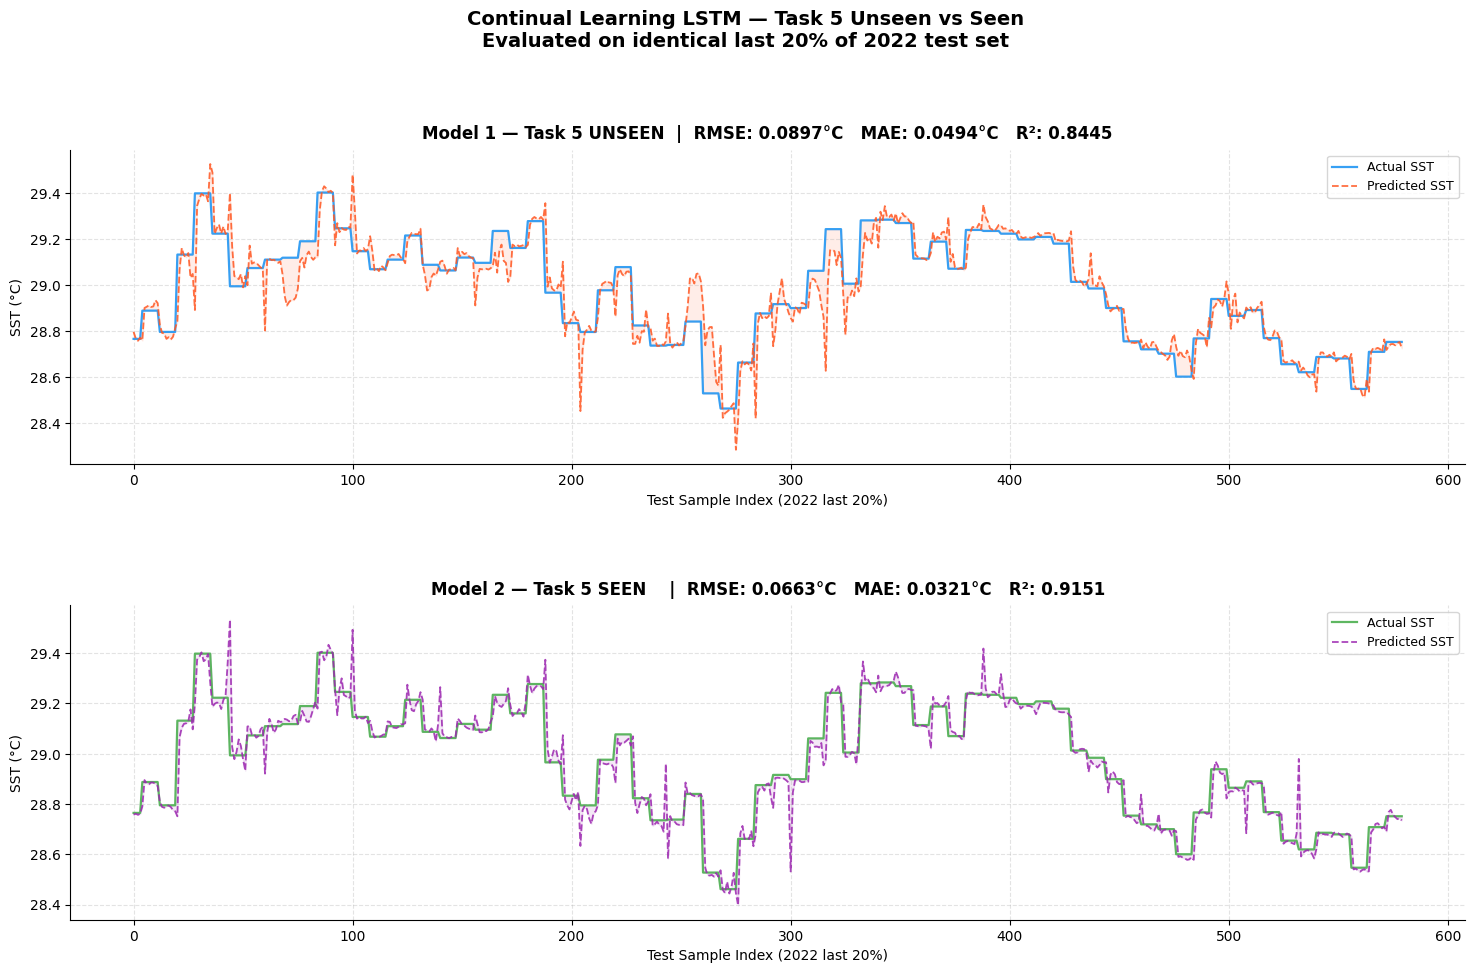

Saved → unseen_vs_seen.png


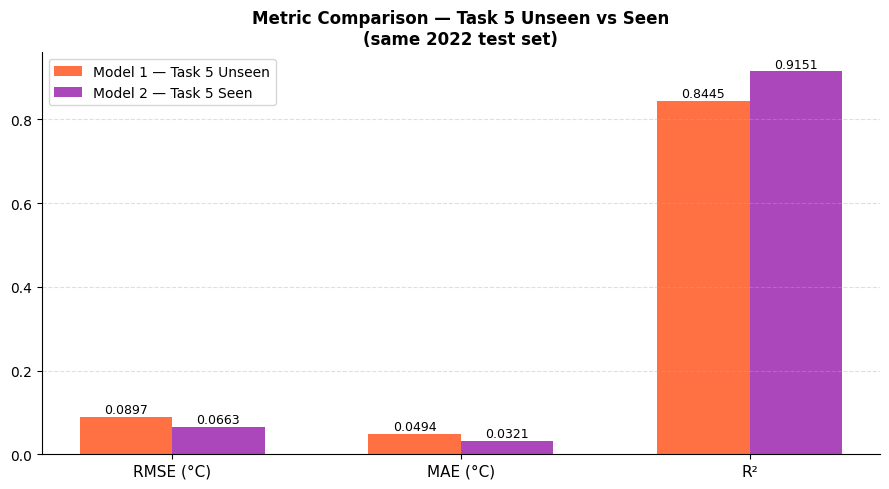

Saved → metric_comparison.png


In [2]:
"""
Continual Learning LSTM — Task 5 Unseen vs Seen Comparison
===========================================================
Two experimental settings on the SAME test set (last 20% of 2022):

  Model 1 (Task 5 Unseen): trained on 2018–2021 only
  Model 2 (Task 5 Seen)  : trained on 2018–2021 + first 80% of 2022

Both models:
  - use identical LSTM architecture
  - train sequentially without reinitialisation
  - are evaluated on the EXACT same 2022 test split
"""

import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ─────────────────────────────────────────────
# 0. CONFIGURATION
# ─────────────────────────────────────────────
TASK_FILES_BASE = {
    2018: "2018.xlsx",
    2019: "2019.xlsx",
    2020: "2020.xlsx",
    2021: "2021.xlsx",
}
FILE_2022   = "2022.xlsx"

SEQ_LEN     = 24
TRAIN_RATIO = 0.80
EPOCHS      = 300
LR          = 0.001
BATCH_SIZE  = 64
INPUT_SIZE  = 1
HIDDEN_SIZE = 64
NUM_LAYERS  = 2

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}\n")


# ─────────────────────────────────────────────
# 1. LSTM MODEL
# ─────────────────────────────────────────────
class SSTLSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers):
        super(SSTLSTMModel, self).__init__()
        self.lstm = nn.LSTM(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            batch_first = True,
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        return self.fc(h_n[-1])


# ─────────────────────────────────────────────
# 2. DATA UTILITIES
# ─────────────────────────────────────────────
def load_sst(filepath):
    df = pd.read_excel(filepath, usecols=["time", "sst"])
    df["time"] = pd.to_datetime(df["time"])
    df = df.sort_values("time").reset_index(drop=True)
    return df["sst"].values.astype(np.float32)


def create_sequences(sst_values, seq_len):
    X, y = [], []
    for i in range(len(sst_values) - seq_len):
        X.append(sst_values[i : i + seq_len])
        y.append(sst_values[i + seq_len])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


def scale_data(X_train, y_train, X_test, y_test):
    """Fit scalers on train only — no test leakage."""
    n_tr, seq_len = X_train.shape

    sx = StandardScaler()
    X_tr_s = sx.fit_transform(X_train.reshape(-1, 1)).reshape(n_tr, seq_len)
    X_te_s = sx.transform(X_test.reshape(-1, 1)).reshape(X_test.shape[0], seq_len)

    sy = StandardScaler()
    y_tr_s = sy.fit_transform(y_train.reshape(-1, 1)).ravel()
    y_te_s = sy.transform(y_test.reshape(-1, 1)).ravel()

    return X_tr_s, y_tr_s, X_te_s, y_te_s, sx, sy


def scale_train_only(X_train, y_train):
    """Scale training data only — returns scaled arrays + fitted scalers."""
    n_tr, seq_len = X_train.shape

    sx = StandardScaler()
    X_tr_s = sx.fit_transform(X_train.reshape(-1, 1)).reshape(n_tr, seq_len)

    sy = StandardScaler()
    y_tr_s = sy.fit_transform(y_train.reshape(-1, 1)).ravel()

    return X_tr_s, y_tr_s, sx, sy


def apply_scalers(X, y, sx, sy, seq_len):
    """Apply already-fitted scalers to new data."""
    X_s = sx.transform(X.reshape(-1, 1)).reshape(X.shape[0], seq_len)
    y_s = sy.transform(y.reshape(-1, 1)).ravel()
    return X_s, y_s


# ─────────────────────────────────────────────
# 3. TRAINING
# ─────────────────────────────────────────────
def train_one_task(model, X_train, y_train, epochs, lr, batch_size, device):
    """Standard MSE training for one task."""
    X_t = torch.tensor(X_train, dtype=torch.float32).unsqueeze(-1).to(device)
    y_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(-1).to(device)

    loader    = DataLoader(TensorDataset(X_t, y_t),
                           batch_size=batch_size, shuffle=True)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    model.train()
    t0 = time.time()

    for epoch in range(1, epochs + 1):
        epoch_loss = 0.0
        for xb, yb in loader:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(xb)
        epoch_loss /= len(X_t)

        if epoch % 50 == 0 or epoch == 1:
            print(f"    Epoch [{epoch:>3}/{epochs}]  Loss: {epoch_loss:.6f}")

    return time.time() - t0


# ─────────────────────────────────────────────
# 4. EVALUATION
# ─────────────────────────────────────────────
def evaluate(model, X_te, y_te_scaled, scaler_y, device):
    model.eval()
    X_t = torch.tensor(X_te, dtype=torch.float32).unsqueeze(-1).to(device)
    with torch.no_grad():
        pred_s = model(X_t).cpu().numpy()

    pred  = scaler_y.inverse_transform(pred_s).ravel()
    truth = scaler_y.inverse_transform(y_te_scaled.reshape(-1, 1)).ravel()

    rmse = np.sqrt(mean_squared_error(truth, pred))
    mae  = mean_absolute_error(truth, pred)
    r2   = r2_score(truth, pred)
    return rmse, mae, r2, truth, pred


# ─────────────────────────────────────────────
# 5. SHARED 2022 TEST SET
# ─────────────────────────────────────────────
def prepare_2022_splits():
    """
    Load 2022 once and produce:
      - train portion  (first 80% of sequences) — used only by Model 2
      - test portion   (last  20% of sequences) — shared by BOTH models

    The split is done on raw sequences BEFORE any scaling so both
    models evaluate on exactly the same 2022 SST values.
    """
    sst_2022 = load_sst(FILE_2022)
    X_2022, y_2022 = create_sequences(sst_2022, SEQ_LEN)

    split = int(len(X_2022) * TRAIN_RATIO)

    X_train_2022 = X_2022[:split]
    y_train_2022 = y_2022[:split]
    X_test_2022  = X_2022[split:]   # ← SHARED test set
    y_test_2022  = y_2022[split:]   # ← SHARED test set

    return X_train_2022, y_train_2022, X_test_2022, y_test_2022


# ─────────────────────────────────────────────
# 6. TRAIN BASE TASKS (2018–2021)
# ─────────────────────────────────────────────
def train_base_tasks(model, verbose_prefix=""):
    """
    Train sequentially on 2018 → 2019 → 2020 → 2021.
    Returns total elapsed time and a log of per-task timing.
    """
    total_time = 0.0
    task_times = {}

    for year, filepath in TASK_FILES_BASE.items():
        print(f"\n  {verbose_prefix}── Task {year} ──")
        sst    = load_sst(filepath)
        X, y   = create_sequences(sst, SEQ_LEN)
        split  = int(len(X) * TRAIN_RATIO)

        X_tr, y_tr, _, _, _, _ = scale_data(
            X[:split], y[:split], X[split:], y[split:]
        )

        elapsed = train_one_task(
            model, X_tr, y_tr, EPOCHS, LR, BATCH_SIZE, DEVICE
        )
        task_times[year] = elapsed
        total_time       += elapsed
        print(f"    Task {year} done in {elapsed:.1f}s")

    return total_time, task_times


# ─────────────────────────────────────────────
# 7. PLOTTING
# ─────────────────────────────────────────────
def plot_comparison(results):
    """
    Side-by-side Actual vs Predicted for Model 1 and Model 2
    on the identical 2022 test set.
    """
    fig = plt.figure(figsize=(18, 10))
    gs  = gridspec.GridSpec(2, 1, hspace=0.45)

    configs = [
        {
            "key"    : "unseen",
            "title"  : (f"Model 1 — Task 5 UNSEEN  |  "
                        f"RMSE: {results['unseen']['rmse']:.4f}°C   "
                        f"MAE: {results['unseen']['mae']:.4f}°C   "
                        f"R²: {results['unseen']['r2']:.4f}"),
            "c_true" : "#2196F3",
            "c_pred" : "#FF5722",
        },
        {
            "key"    : "seen",
            "title"  : (f"Model 2 — Task 5 SEEN    |  "
                        f"RMSE: {results['seen']['rmse']:.4f}°C   "
                        f"MAE: {results['seen']['mae']:.4f}°C   "
                        f"R²: {results['seen']['r2']:.4f}"),
            "c_true" : "#4CAF50",
            "c_pred" : "#9C27B0",
        },
    ]

    for i, cfg in enumerate(configs):
        ax     = fig.add_subplot(gs[i])
        data   = results[cfg["key"]]
        y_true = data["y_true"]
        y_pred = data["y_pred"]
        x_axis = np.arange(len(y_true))

        ax.plot(x_axis, y_true,
                color=cfg["c_true"], linewidth=1.6,
                label="Actual SST", alpha=0.9)
        ax.plot(x_axis, y_pred,
                color=cfg["c_pred"], linewidth=1.3,
                linestyle="--", label="Predicted SST", alpha=0.85)
        ax.fill_between(x_axis, y_true, y_pred,
                        alpha=0.10, color=cfg["c_pred"])

        ax.set_title(cfg["title"], fontsize=12,
                     fontweight="bold", pad=8)
        ax.set_xlabel("Test Sample Index (2022 last 20%)", fontsize=10)
        ax.set_ylabel("SST (°C)", fontsize=10)
        ax.legend(loc="upper right", fontsize=9)
        ax.grid(True, linestyle="--", alpha=0.35)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    fig.suptitle(
        "Continual Learning LSTM — Task 5 Unseen vs Seen\n"
        "Evaluated on identical last 20% of 2022 test set",
        fontsize=14, fontweight="bold", y=1.02
    )
    plt.savefig("unseen_vs_seen.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved → unseen_vs_seen.png")


def plot_metric_comparison(results):
    """
    Bar chart comparing RMSE, MAE, R² side by side.
    """
    metrics = ["RMSE (°C)", "MAE (°C)", "R²"]
    unseen_vals = [
        results["unseen"]["rmse"],
        results["unseen"]["mae"],
        results["unseen"]["r2"],
    ]
    seen_vals = [
        results["seen"]["rmse"],
        results["seen"]["mae"],
        results["seen"]["r2"],
    ]

    x     = np.arange(len(metrics))
    width = 0.32

    fig, ax = plt.subplots(figsize=(9, 5))
    bars1 = ax.bar(x - width/2, unseen_vals, width,
                   label="Model 1 — Task 5 Unseen",
                   color="#FF5722", alpha=0.85)
    bars2 = ax.bar(x + width/2, seen_vals, width,
                   label="Model 2 — Task 5 Seen",
                   color="#9C27B0", alpha=0.85)

    # value labels on bars
    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.001,
                f"{bar.get_height():.4f}",
                ha="center", va="bottom", fontsize=9)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.001,
                f"{bar.get_height():.4f}",
                ha="center", va="bottom", fontsize=9)

    ax.set_xticks(x)
    ax.set_xticklabels(metrics, fontsize=11)
    ax.set_title(
        "Metric Comparison — Task 5 Unseen vs Seen\n(same 2022 test set)",
        fontsize=12, fontweight="bold"
    )
    ax.legend(fontsize=10)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.savefig("metric_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved → metric_comparison.png")


# ─────────────────────────────────────────────
# 8. MAIN
# ─────────────────────────────────────────────
def main():

    # ── Prepare shared 2022 splits ───────────────────────────────
    # Both models evaluate on the exact same sequences
    print("Preparing 2022 splits …")
    X_train_2022, y_train_2022, X_test_2022, y_test_2022 = prepare_2022_splits()
    print(f"  2022 train sequences : {len(X_train_2022)}")
    print(f"  2022 test  sequences : {len(X_test_2022)}  ← shared test set\n")

    results = {}

    # ════════════════════════════════════════════════════════════
    # MODEL 1 — Task 5 UNSEEN
    # Train only on 2018–2021, evaluate on 2022 test
    # ════════════════════════════════════════════════════════════
    print("=" * 65)
    print("  MODEL 1 — Task 5 UNSEEN (train: 2018–2021)")
    print("=" * 65)

    model1 = SSTLSTMModel(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS).to(DEVICE)

    time1_base, _ = train_base_tasks(model1, verbose_prefix="[M1] ")

    # Scale 2022 test using a scaler fit on 2021 train
    # (model1 has never seen 2022 — we must use a past-year scaler)
    # We fit a fresh scaler on 2022 train portion to properly
    # inverse-transform, but DO NOT train the model on it.
    sx_2022_m1 = StandardScaler()
    sx_2022_m1.fit(X_train_2022.reshape(-1, 1))
    sy_2022_m1 = StandardScaler()
    sy_2022_m1.fit(y_train_2022.reshape(-1, 1))

    X_te_2022_m1 = sx_2022_m1.transform(
        X_test_2022.reshape(-1, 1)
    ).reshape(X_test_2022.shape[0], SEQ_LEN)
    y_te_2022_m1 = sy_2022_m1.transform(
        y_test_2022.reshape(-1, 1)
    ).ravel()

    rmse1, mae1, r2_1, y_true1, y_pred1 = evaluate(
        model1, X_te_2022_m1, y_te_2022_m1, sy_2022_m1, DEVICE
    )

    print(f"\n  ── Model 1 Results on 2022 test set ──")
    print(f"  RMSE          : {rmse1:.4f} °C")
    print(f"  MAE           : {mae1:.4f} °C")
    print(f"  R²            : {r2_1:.4f}")
    print(f"  Training time : {time1_base:.2f} s  (2018–2021 only)\n")

    results["unseen"] = {
        "rmse"  : rmse1,
        "mae"   : mae1,
        "r2"    : r2_1,
        "y_true": y_true1,
        "y_pred": y_pred1,
        "time"  : time1_base,
    }

    # ════════════════════════════════════════════════════════════
    # MODEL 2 — Task 5 SEEN
    # Train on 2018–2021 THEN first 80% of 2022, evaluate on same test
    # ════════════════════════════════════════════════════════════
    print("=" * 65)
    print("  MODEL 2 — Task 5 SEEN (train: 2018–2021 + 2022 train)")
    print("=" * 65)

    model2 = SSTLSTMModel(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS).to(DEVICE)

    time2_base, _ = train_base_tasks(model2, verbose_prefix="[M2] ")

    # Now train model2 on the 2022 training portion
    print(f"\n  [M2]── Task 2022 (train portion only) ──")
    X_tr_2022_s, y_tr_2022_s, sx_2022_m2, sy_2022_m2 = scale_train_only(
        X_train_2022, y_train_2022
    )

    time2_task5 = train_one_task(
        model2, X_tr_2022_s, y_tr_2022_s,
        EPOCHS, LR, BATCH_SIZE, DEVICE
    )
    print(f"    Task 2022 train done in {time2_task5:.1f}s")

    # Scale 2022 test using the SAME scaler fit on 2022 train
    X_te_2022_m2 = sx_2022_m2.transform(
        X_test_2022.reshape(-1, 1)
    ).reshape(X_test_2022.shape[0], SEQ_LEN)
    y_te_2022_m2 = sy_2022_m2.transform(
        y_test_2022.reshape(-1, 1)
    ).ravel()

    rmse2, mae2, r2_2, y_true2, y_pred2 = evaluate(
        model2, X_te_2022_m2, y_te_2022_m2, sy_2022_m2, DEVICE
    )

    time2_total = time2_base + time2_task5
    print(f"\n  ── Model 2 Results on 2022 test set ──")
    print(f"  RMSE          : {rmse2:.4f} °C")
    print(f"  MAE           : {mae2:.4f} °C")
    print(f"  R²            : {r2_2:.4f}")
    print(f"  Training time : {time2_total:.2f} s  (2018–2022 train)\n")

    results["seen"] = {
        "rmse"  : rmse2,
        "mae"   : mae2,
        "r2"    : r2_2,
        "y_true": y_true2,
        "y_pred": y_pred2,
        "time"  : time2_total,
    }

    # ── Final comparison table ───────────────────────────────────
    print("\n" + "=" * 65)
    print("  FINAL COMPARISON — same 2022 test set")
    print("=" * 65)
    print(f"  {'Metric':<20} {'Model 1 (Unseen)':>18} {'Model 2 (Seen)':>16}")
    print(f"  {'-'*20} {'-'*18} {'-'*16}")
    print(f"  {'RMSE (°C)':<20} {rmse1:>18.4f} {rmse2:>16.4f}")
    print(f"  {'MAE  (°C)':<20} {mae1:>18.4f} {mae2:>16.4f}")
    print(f"  {'R²':<20} {r2_1:>18.4f} {r2_2:>16.4f}")
    print(f"  {'Train Time (s)':<20} {time1_base:>18.2f} {time2_total:>16.2f}")
    print("=" * 65)

    # ── Plots ────────────────────────────────────────────────────
    plot_comparison(results)
    plot_metric_comparison(results)

    return model1, model2, results


if __name__ == "__main__":
    model1, model2, results = main()

In [1]:
"""
Multi-Lag LSTM for SST Prediction
===================================
Four parallel LSTM branches each processing a different lag window:
  Branch 1 → last 3  hours  (seq_len=1, step=1)
  Branch 2 → last 6  hours  (seq_len=2, step=1)
  Branch 3 → last 24 hours  (seq_len=8, step=1)
  Branch 4 → last 72 hours  (seq_len=24, step=1)

Each branch has its own 2-layer LSTM.
All four last hidden states are concatenated → FC → SST prediction.
"""

import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ─────────────────────────────────────────────
# 0. CONFIG
# ─────────────────────────────────────────────
TASK_FILES = {
    2018: "2018.xlsx",
    2019: "2019.xlsx",
    2020: "2020.xlsx",
    2021: "2021.xlsx",
    2022: "2022.xlsx",
}

# Each sample is 3 hours apart.
# Lag  3h  = 1 step  back
# Lag  6h  = 2 steps back
# Lag 24h  = 8 steps back
# Lag 72h  = 24 steps back
LAG_STEPS = {
    "lag_3h" : 1,
    "lag_6h" : 2,
    "lag_24h": 8,
    "lag_72h": 24,
}
MAX_LAG     = max(LAG_STEPS.values())   # 24 — how far back we need
HIDDEN_SIZE = 64
NUM_LAYERS  = 2
TRAIN_RATIO = 0.80
EPOCHS      = 300
LR          = 0.001
BATCH_SIZE  = 64

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}\n")


# ─────────────────────────────────────────────
# 1. MULTI-LAG LSTM MODEL
# ─────────────────────────────────────────────
class MultiLagLSTM(nn.Module):
    """
    Four independent LSTM branches, one per lag window.
    Each branch:
        input  : (batch, seq_len_i, 1)
        output : last hidden state h → (batch, hidden_size)

    All four hidden states are concatenated:
        cat([h1, h2, h3, h4])  →  (batch, hidden_size * 4)

    Then passed through one FC layer:
        Linear(hidden_size * 4 → 1)  →  (batch, 1)
    """
    def __init__(self, hidden_size, num_layers):
        super(MultiLagLSTM, self).__init__()

        # one LSTM per lag — each sees its own seq_len during forward pass
        self.lstm_3h  = nn.LSTM(1, hidden_size, num_layers, batch_first=True)
        self.lstm_6h  = nn.LSTM(1, hidden_size, num_layers, batch_first=True)
        self.lstm_24h = nn.LSTM(1, hidden_size, num_layers, batch_first=True)
        self.lstm_72h = nn.LSTM(1, hidden_size, num_layers, batch_first=True)

        # FC takes all four hidden states joined together
        self.fc = nn.Linear(hidden_size * 4, 1)

    def _last_hidden(self, lstm, x):
        """Run one LSTM branch and return the last-layer hidden state."""
        # x    : (batch, seq_len, 1)
        # h_n  : (num_layers, batch, hidden_size)
        _, (h_n, _) = lstm(x)
        return h_n[-1]              # (batch, hidden_size)

    def forward(self, x_3h, x_6h, x_24h, x_72h):
        """
        Parameters
        ----------
        x_3h  : (batch, 1,  1)
        x_6h  : (batch, 2,  1)
        x_24h : (batch, 8,  1)
        x_72h : (batch, 24, 1)
        """
        h1 = self._last_hidden(self.lstm_3h,  x_3h)    # (batch, 64)
        h2 = self._last_hidden(self.lstm_6h,  x_6h)    # (batch, 64)
        h3 = self._last_hidden(self.lstm_24h, x_24h)   # (batch, 64)
        h4 = self._last_hidden(self.lstm_72h, x_72h)   # (batch, 64)

        # Concatenate along feature dim → (batch, 256)
        combined = torch.cat([h1, h2, h3, h4], dim=1)

        return self.fc(combined)    # (batch, 1)


# ─────────────────────────────────────────────
# 2. DATA UTILITIES
# ─────────────────────────────────────────────
def load_and_preprocess(filepath):
    df = pd.read_excel(filepath, usecols=["time", "sst"])
    df["time"] = pd.to_datetime(df["time"])
    df = df.sort_values("time").reset_index(drop=True)
    return df["sst"].values.astype(np.float32)


def create_multi_lag_sequences(sst_values, lag_steps):
    """
    Build aligned input/target arrays for all four lag windows.

    For each valid position t (starting at MAX_LAG):
        x_3h  = sst[t-1  : t]             shape (1,)
        x_6h  = sst[t-2  : t]             shape (2,)
        x_24h = sst[t-8  : t]             shape (8,)
        x_72h = sst[t-24 : t]             shape (24,)
        y     = sst[t]                     scalar

    Returns dict of arrays + target array.
    """
    max_lag = max(lag_steps.values())
    n       = len(sst_values)

    sequences = {name: [] for name in lag_steps}
    targets   = []

    for t in range(max_lag, n):
        for name, steps in lag_steps.items():
            sequences[name].append(sst_values[t - steps : t])
        targets.append(sst_values[t])

    return (
        {name: np.array(seq, dtype=np.float32)
         for name, seq in sequences.items()},
        np.array(targets, dtype=np.float32)
    )


def split_and_scale(sequences, targets, train_ratio):
    """
    80/20 split then scale each lag branch independently.
    Target gets its own scaler.
    Returns scaled train/test dicts, target arrays, and scalers.
    """
    n     = len(targets)
    split = int(n * train_ratio)

    train_seqs = {k: v[:split] for k, v in sequences.items()}
    test_seqs  = {k: v[split:] for k, v in sequences.items()}
    y_train    = targets[:split]
    y_test     = targets[split:]

    # scale each lag branch with its own scaler (fit on train only)
    scalers_X = {}
    train_scaled = {}
    test_scaled  = {}

    for name, X_tr in train_seqs.items():
        seq_len = X_tr.shape[1]
        sx = StandardScaler()
        train_scaled[name] = sx.fit_transform(
            X_tr.reshape(-1, 1)
        ).reshape(-1, seq_len)
        test_scaled[name]  = sx.transform(
            test_seqs[name].reshape(-1, 1)
        ).reshape(-1, seq_len)
        scalers_X[name] = sx

    # target scaler
    sy = StandardScaler()
    y_train_s = sy.fit_transform(y_train.reshape(-1, 1)).ravel()
    y_test_s  = sy.transform(y_test.reshape(-1, 1)).ravel()

    return train_scaled, y_train_s, test_scaled, y_test_s, scalers_X, sy


def to_tensors(scaled_dict, y_scaled, device):
    """Convert scaled numpy dicts to CUDA/CPU tensors."""
    tensors = {}
    for name, arr in scaled_dict.items():
        # (n, seq_len) → (n, seq_len, 1)
        tensors[name] = torch.tensor(
            arr, dtype=torch.float32
        ).unsqueeze(-1).to(device)

    y_t = torch.tensor(
        y_scaled, dtype=torch.float32
    ).unsqueeze(-1).to(device)

    return tensors, y_t


# ─────────────────────────────────────────────
# 3. TRAINING
# ─────────────────────────────────────────────
def train_model(model, train_scaled, y_train_s, epochs, lr,
                batch_size, device):
    """Train the multi-lag LSTM with MSE loss."""

    tensors, y_t = to_tensors(train_scaled, y_train_s, device)

    dataset = TensorDataset(
        tensors["lag_3h"],
        tensors["lag_6h"],
        tensors["lag_24h"],
        tensors["lag_72h"],
        y_t
    )
    loader    = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    model.train()
    t0 = time.time()

    for epoch in range(1, epochs + 1):
        epoch_loss = 0.0
        for x3, x6, x24, x72, yb in loader:
            optimizer.zero_grad()
            pred = model(x3, x6, x24, x72)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(yb)

        epoch_loss /= len(dataset)
        if epoch % 50 == 0 or epoch == 1:
            print(f"  Epoch [{epoch:>3}/{epochs}]  Loss: {epoch_loss:.6f}")

    return time.time() - t0


# ─────────────────────────────────────────────
# 4. EVALUATION
# ─────────────────────────────────────────────
def evaluate_model(model, test_scaled, y_test_s, scaler_y, device):
    model.eval()
    tensors, _ = to_tensors(test_scaled, y_test_s, device)

    with torch.no_grad():
        preds_s = model(
            tensors["lag_3h"],
            tensors["lag_6h"],
            tensors["lag_24h"],
            tensors["lag_72h"]
        ).cpu().numpy()

    preds = scaler_y.inverse_transform(preds_s).ravel()
    truth = scaler_y.inverse_transform(
        y_test_s.reshape(-1, 1)
    ).ravel()

    rmse = np.sqrt(mean_squared_error(truth, preds))
    mae  = mean_absolute_error(truth, preds)
    r2   = r2_score(truth, preds)

    return rmse, mae, r2, truth, preds


# ─────────────────────────────────────────────
# 5. MAIN
# ─────────────────────────────────────────────
def main():
    model        = MultiLagLSTM(HIDDEN_SIZE, NUM_LAYERS).to(DEVICE)
    task_results = {}
    all_rmse, all_mae, all_r2, all_times = [], [], [], []

    for year, filepath in TASK_FILES.items():
        print("=" * 60)
        print(f"  TASK: {year}")
        print("=" * 60)

        sst     = load_and_preprocess(filepath)
        seqs, y = create_multi_lag_sequences(sst, LAG_STEPS)
        print(f"  Total samples: {len(y)}")

        tr_scaled, y_tr, te_scaled, y_te, scalers_X, scaler_y = \
            split_and_scale(seqs, y, TRAIN_RATIO)
        print(f"  Train: {len(y_tr)}  |  Test: {len(y_te)}")

        print(f"\n  Training for {EPOCHS} epochs …")
        elapsed = train_model(
            model, tr_scaled, y_tr, EPOCHS, LR, BATCH_SIZE, DEVICE
        )

        rmse, mae, r2, y_true, y_pred = evaluate_model(
            model, te_scaled, y_te, scaler_y, DEVICE
        )

        task_results[year] = {"y_true": y_true, "y_pred": y_pred}

        print(f"\n  ── Metrics for Task {year} ──")
        print(f"  RMSE          : {rmse:.4f} °C")
        print(f"  MAE           : {mae:.4f} °C")
        print(f"  R²            : {r2:.4f}")
        print(f"  Training time : {elapsed:.2f} s\n")

        all_rmse.append(rmse)
        all_mae.append(mae)
        all_r2.append(r2)
        all_times.append(elapsed)

    print("\n" + "=" * 60)
    print("  FINAL SUMMARY")
    print("=" * 60)
    print(f"  Average RMSE        : {np.mean(all_rmse):.4f} °C")
    print(f"  Average MAE         : {np.mean(all_mae):.4f} °C")
    print(f"  Average R²          : {np.mean(all_r2):.4f}")
    print(f"  Total Training Time : {sum(all_times):.2f} s")
    print("=" * 60)

    return model, task_results, scaler_y, te_scaled, y_te


if __name__ == "__main__":
    model, task_results, scaler_y, te_scaled, y_te = main()

Using device: cpu

  TASK: 2018
  Total samples: 2896
  Train: 2316  |  Test: 580

  Training for 300 epochs …
  Epoch [  1/300]  Loss: 0.418303
  Epoch [ 50/300]  Loss: 0.006452
  Epoch [100/300]  Loss: 0.005545
  Epoch [150/300]  Loss: 0.005405
  Epoch [200/300]  Loss: 0.005376
  Epoch [250/300]  Loss: 0.005236
  Epoch [300/300]  Loss: 0.005020

  ── Metrics for Task 2018 ──
  RMSE          : 0.0479 °C
  MAE           : 0.0212 °C
  R²            : 0.9588
  Training time : 459.32 s

  TASK: 2019
  Total samples: 2896
  Train: 2316  |  Test: 580

  Training for 300 epochs …
  Epoch [  1/300]  Loss: 0.008621
  Epoch [ 50/300]  Loss: 0.008215
  Epoch [100/300]  Loss: 0.008027
  Epoch [150/300]  Loss: 0.007358
  Epoch [200/300]  Loss: 0.006515
  Epoch [250/300]  Loss: 0.006555
  Epoch [300/300]  Loss: 0.006184

  ── Metrics for Task 2019 ──
  RMSE          : 0.0618 °C
  MAE           : 0.0258 °C
  R²            : 0.9444
  Training time : 375.63 s

  TASK: 2020
  Total samples: 2904
  Trai

In [9]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

# ── Config ────────────────────────────────────────
SEQ_LEN    = 3    # 24 × 3h = 72h look-back
EPOCHS     = 200
LR         = 0.001
BATCH_SIZE = 128
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# ── Load ──────────────────────────────────────────
df2018 = pd.read_excel("2018.xlsx")

# ── Preprocess ────────────────────────────────────
def preprocess(df):
    df = df[["time", "sst"]].copy()
    df["time"] = pd.to_datetime(df["time"])
    df = df.sort_values("time").reset_index(drop=True)
    return df

df2018 = preprocess(df2018)

# ── Sequences ─────────────────────────────────────
def create_sequences(df, seq_len):
    values = df["sst"].values.astype(np.float32)
    X, y = [], []
    for i in range(len(values) - seq_len):
        X.append(values[i : i + seq_len])
        y.append(values[i + seq_len])
    return np.array(X), np.array(y)

X, y = create_sequences(df2018, SEQ_LEN)

split   = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# ── Scale ─────────────────────────────────────────
sx = StandardScaler()
X_train_s = sx.fit_transform(X_train.reshape(-1,1)).reshape(X_train.shape)
X_test_s  = sx.transform(X_test.reshape(-1,1)).reshape(X_test.shape)

sy = StandardScaler()
y_train_s = sy.fit_transform(y_train.reshape(-1,1)).ravel()

# ── Tensors ───────────────────────────────────────
X_tr = torch.tensor(X_train_s, dtype=torch.float32).unsqueeze(-1).to(DEVICE)
X_te = torch.tensor(X_test_s,  dtype=torch.float32).unsqueeze(-1).to(DEVICE)
y_tr = torch.tensor(y_train_s, dtype=torch.float32).unsqueeze(-1).to(DEVICE)

loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=BATCH_SIZE, shuffle=True)

# ── Model ─────────────────────────────────────────
class LSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=32,
                            num_layers=2, batch_first=True)
        self.fc = nn.Linear(32, 1)

    def forward(self, x):
        _, (hn, _) = self.lstm(x)
        return self.fc(hn[-1])          # last layer hidden state

model     = LSTMModel().to(DEVICE)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# ── Train ─────────────────────────────────────────
for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss = 0.0
    for xb, yb in loader:
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(xb)
    if epoch % 50 == 0 or epoch == 1:
        print(f"Epoch [{epoch:>3}/{EPOCHS}]  Loss: {epoch_loss/len(X_tr):.6f}")

# ── Evaluate ──────────────────────────────────────
model.eval()
with torch.no_grad():
    preds_s = model(X_te).cpu().numpy()

preds = sy.inverse_transform(preds_s).ravel()
rmse  = np.sqrt(mean_squared_error(y_test, preds))
r2    = r2_score(y_test, preds)
print(f"\nRMSE : {rmse:.4f} °C")
print(f"R²   : {r2:.4f}")

Using device: cpu
Epoch [  1/200]  Loss: 0.950221
Epoch [ 50/200]  Loss: 0.008558
Epoch [100/200]  Loss: 0.005938
Epoch [150/200]  Loss: 0.005699
Epoch [200/200]  Loss: 0.005426

RMSE : 0.0483 °C
R²   : 0.9580


In [12]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import pandas as pd
import time

# ── Config (kept from your code) ─────────────────
SEQ_LEN      = 3
EPOCHS       = 200
LR           = 0.001
BATCH_SIZE   = 256
EWC_LAMBDA   = 1000
FISHER_SAMPLES = 200

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

TASK_FILES = {
    2018: "2018.xlsx",
    2019: "2019.xlsx",
    2020: "2020.xlsx",
    2021: "2021.xlsx",
    2022: "2022.xlsx",
}

# ── Preprocess ────────────────────────────────────
def preprocess(df):
    df = df[["time", "sst"]].copy()
    df["time"] = pd.to_datetime(df["time"])
    df = df.sort_values("time").reset_index(drop=True)
    return df

# ── Sequences ─────────────────────────────────────
def create_sequences(df, seq_len):
    values = df["sst"].values.astype(np.float32)
    X, y = [], []
    for i in range(len(values) - seq_len):
        X.append(values[i : i + seq_len])
        y.append(values[i + seq_len])
    return np.array(X), np.array(y)

# ── Scale ─────────────────────────────────────────
def scale_data(X_train, y_train, X_test, y_test):
    sx = StandardScaler()
    X_tr_s = sx.fit_transform(
        X_train.reshape(-1, 1)
    ).reshape(X_train.shape)
    X_te_s = sx.transform(
        X_test.reshape(-1, 1)
    ).reshape(X_test.shape)

    sy = StandardScaler()
    y_tr_s = sy.fit_transform(
        y_train.reshape(-1, 1)
    ).ravel()

    return X_tr_s, y_tr_s, X_te_s, sx, sy

# ── Model (kept from your code) ───────────────────
class LSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=32,
            num_layers=2,
            batch_first=True
        )
        self.fc = nn.Linear(32, 1)

    def forward(self, x):
        _, (hn, _) = self.lstm(x)
        return self.fc(hn[-1])

# ── EWC ───────────────────────────────────────────
class EWC:
    """
    After each task:
      1. Save a snapshot of weights (theta*)
      2. Compute Fisher diagonal (importance of each weight)

    During next task training:
      total_loss = MSE + (lambda/2) * sum[ F_i * (W_i - W*_i)^2 ]

    High Fisher weight → strongly protected → can't move much
    Low Fisher weight  → free to adapt to new task
    """

    def __init__(self):
        self.fisher_list  = []   # one dict per completed task
        self.optimal_list = []   # one dict per completed task

    def compute_fisher(self, model, X_sample, y_sample):
        model.eval()
        criterion = nn.MSELoss()

        # initialise Fisher to zero for every parameter
        fisher = {
            n: torch.zeros_like(p)
            for n, p in model.named_parameters()
        }

        X_t = torch.tensor(
            X_sample, dtype=torch.float32
        ).unsqueeze(-1).to(DEVICE)

        y_t = torch.tensor(
            y_sample, dtype=torch.float32
        ).unsqueeze(-1).to(DEVICE)

        # accumulate squared gradients sample by sample
        for i in range(len(X_t)):
            model.zero_grad()
            pred = model(X_t[i].unsqueeze(0))
            loss = criterion(pred, y_t[i].unsqueeze(0))
            loss.backward()

            for n, p in model.named_parameters():
                if p.grad is not None:
                    fisher[n] += p.grad.data.clone() ** 2

        # average over all samples
        for n in fisher:
            fisher[n] /= len(X_t)

        return fisher

    def register_task(self, model, X_train, y_train):
        print(f"  Computing Fisher on {len(X_train)} samples ...", end=" ")

        # random subset for Fisher estimation
        idx = np.random.choice(
            len(X_train),
            size=min(FISHER_SAMPLES, len(X_train)),
            replace=False
        )

        fisher = self.compute_fisher(model, X_train[idx], y_train[idx])
        self.fisher_list.append(fisher)

        # save weight snapshot
        weights = {
            n: p.data.clone()
            for n, p in model.named_parameters()
        }
        self.optimal_list.append(weights)

        print(f"done. Tasks registered: {len(self.fisher_list)}")

    def penalty(self, model):
        """
        Returns EWC penalty term.
        Zero on first task (nothing registered yet).
        """
        if not self.fisher_list:
            return torch.tensor(0.0, device=DEVICE)

        penalty = torch.tensor(0.0, device=DEVICE)

        for fisher, optimal in zip(self.fisher_list, self.optimal_list):
            for n, p in model.named_parameters():
                if n in fisher:
                    f     = fisher[n].to(DEVICE)
                    w_opt = optimal[n].to(DEVICE)
                    penalty += (f * (p - w_opt) ** 2).sum()

        return (EWC_LAMBDA / 2) * penalty

# ── Train one task with EWC loss ──────────────────
def train_task(model, ewc, X_tr_s, y_tr_s):
    X_t = torch.tensor(
        X_tr_s, dtype=torch.float32
    ).unsqueeze(-1).to(DEVICE)

    y_t = torch.tensor(
        y_tr_s, dtype=torch.float32
    ).unsqueeze(-1).to(DEVICE)

    loader    = DataLoader(
        TensorDataset(X_t, y_t),
        batch_size=BATCH_SIZE,
        shuffle=True
    )
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    criterion = nn.MSELoss()

    t0 = time.time()
    model.train()

    for epoch in range(1, EPOCHS + 1):
        epoch_loss = epoch_mse = epoch_ewc = 0.0

        for xb, yb in loader:
            optimizer.zero_grad()

            pred     = model(xb)
            loss_mse = criterion(pred, yb)

            # EWC penalty — zero on task 1
            loss_ewc = ewc.penalty(model)

            # combined loss — this is the key difference from plain LSTM
            loss = loss_mse + loss_ewc

            loss.backward()
            optimizer.step()

            n = len(xb)
            epoch_loss += loss.item()     * n
            epoch_mse  += loss_mse.item() * n
            epoch_ewc  += loss_ewc.item() * n

        N = len(X_t)
        if epoch % 50 == 0 or epoch == 1:
            print(
                f"  Epoch [{epoch:>3}/{EPOCHS}]"
                f"  Total: {epoch_loss/N:.6f}"
                f"  MSE: {epoch_mse/N:.6f}"
                f"  EWC: {epoch_ewc/N:.6f}"
            )

    return time.time() - t0

# ── Evaluate ──────────────────────────────────────
def evaluate(model, X_te_s, y_test, sy):
    model.eval()
    X_t = torch.tensor(
        X_te_s, dtype=torch.float32
    ).unsqueeze(-1).to(DEVICE)

    with torch.no_grad():
        preds_s = model(X_t).cpu().numpy()

    preds = sy.inverse_transform(preds_s).ravel()

    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae  = mean_absolute_error(y_test, preds)
    r2   = r2_score(y_test, preds)

    return rmse, mae, r2, preds

# ── Main loop ─────────────────────────────────────
def main():
    model        = LSTMModel().to(DEVICE)
    ewc          = EWC()
    task_results = {}
    all_rmse, all_mae, all_r2, all_times = [], [], [], []

    for year, filepath in TASK_FILES.items():
        print("=" * 55)
        print(f"  TASK {year}")
        print("=" * 55)

        df  = preprocess(pd.read_excel(filepath))
        X, y = create_sequences(df, SEQ_LEN)

        split = int(len(X) * 0.8)
        X_train, X_test = X[:split], X[split:]
        y_train, y_test = y[:split], y[split:]
        print(f"  Sequences — train: {len(X_train)}  test: {len(X_test)}")

        X_tr_s, y_tr_s, X_te_s, sx, sy = scale_data(
            X_train, y_train, X_test, y_test
        )

        print(f"  Training {EPOCHS} epochs ...")
        elapsed = train_task(model, ewc, X_tr_s, y_tr_s)

        rmse, mae, r2, preds = evaluate(model, X_te_s, y_test, sy)

        task_results[year] = {
            "y_true": y_test,
            "y_pred": preds
        }

        print(f"\n  ── Results {year} ──────────────────")
        print(f"  RMSE          : {rmse:.4f} °C")
        print(f"  MAE           : {mae:.4f} °C")
        print(f"  R²            : {r2:.4f}")
        print(f"  Training time : {elapsed:.1f} s\n")

        all_rmse.append(rmse)
        all_mae.append(mae)
        all_r2.append(r2)
        all_times.append(elapsed)

        # register this task with EWC before moving to next year
        ewc.register_task(model, X_tr_s, y_tr_s)

    print("\n" + "=" * 55)
    print("  SUMMARY")
    print("=" * 55)
    print(f"  Avg RMSE  : {np.mean(all_rmse):.4f} °C")
    print(f"  Avg MAE   : {np.mean(all_mae):.4f} °C")
    print(f"  Avg R²    : {np.mean(all_r2):.4f}")
    print(f"  Total time: {sum(all_times):.1f} s")
    print("=" * 55)

    return model, task_results

if __name__ == "__main__":
    model, task_results = main()

Using device: cpu
  TASK 2018
  Sequences — train: 2333  test: 584
  Training 200 epochs ...
  Epoch [  1/200]  Total: 0.969345  MSE: 0.969345  EWC: 0.000000
  Epoch [ 50/200]  Total: 0.009650  MSE: 0.009650  EWC: 0.000000
  Epoch [100/200]  Total: 0.008637  MSE: 0.008637  EWC: 0.000000
  Epoch [150/200]  Total: 0.006745  MSE: 0.006745  EWC: 0.000000
  Epoch [200/200]  Total: 0.005782  MSE: 0.005782  EWC: 0.000000

  ── Results 2018 ──────────────────
  RMSE          : 0.0483 °C
  MAE           : 0.0195 °C
  R²            : 0.9579
  Training time : 16.4 s

  Computing Fisher on 2333 samples ... done. Tasks registered: 1
  TASK 2019
  Sequences — train: 2333  test: 584
  Training 200 epochs ...
  Epoch [  1/200]  Total: 0.010121  MSE: 0.010044  EWC: 0.000078
  Epoch [ 50/200]  Total: 0.008440  MSE: 0.008405  EWC: 0.000036
  Epoch [100/200]  Total: 0.008590  MSE: 0.008544  EWC: 0.000046
  Epoch [150/200]  Total: 0.008371  MSE: 0.008326  EWC: 0.000045
  Epoch [200/200]  Total: 0.008257  M

In [15]:
"""
EWC (Elastic Weight Consolidation) + LSTM for SST Prediction
=============================================================
Continual Learning without Replay.
Catastrophic forgetting is prevented by adding a penalty term
to the loss function that protects weights that were important
for previous tasks — identified via the Fisher Information Matrix.

Tasks trained sequentially: 2018 → 2019 → 2020 → 2021 → 2022
"""

import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from copy import deepcopy

# ─────────────────────────────────────────────
# 0. CONFIGURATION
# ─────────────────────────────────────────────
TASK_FILES = {
    2018: "2018.xlsx",
    2019: "2019.xlsx",
    2020: "2020.xlsx",
    2021: "2021.xlsx",
    2022: "2022.xlsx",
}

SEQ_LEN     = 6       # 24 × 3h = 72h look-back window
TRAIN_RATIO = 0.80
EPOCHS      = 200
LR          = 0.001
BATCH_SIZE  = 256
INPUT_SIZE  = 1
HIDDEN_SIZE = 32
NUM_LAYERS  = 2

# ── EWC specific ──────────────────────────────
# How strongly to protect old task weights.
# Higher = less forgetting but slower adaptation to new tasks.
# Lower  = faster adaptation but more forgetting.
EWC_LAMBDA  = 50

# Number of samples used to estimate the Fisher matrix.
# More samples = more accurate Fisher but slower computation.
FISHER_SAMPLES = 200

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}\n")


# ─────────────────────────────────────────────
# 1. LSTM MODEL
# ─────────────────────────────────────────────
class SSTLSTMModel(nn.Module):
    """
    Two-layer LSTM followed by a single FC output layer.
    Last hidden state of the final LSTM layer → prediction.
    """
    def __init__(self, input_size, hidden_size, num_layers):
        super(SSTLSTMModel, self).__init__()
        self.lstm = nn.LSTM(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            batch_first = True,
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x: (batch, seq_len, 1)
        _, (h_n, _) = self.lstm(x)
        last_hidden  = h_n[-1]          # (batch, hidden_size)
        return self.fc(last_hidden)     # (batch, 1)


# ─────────────────────────────────────────────
# 2. EWC CLASS
# ─────────────────────────────────────────────
class EWC:
    """
    Elastic Weight Consolidation.

    After finishing each task:
      1. Save a snapshot of current weights as the "optimal" point (theta*)
      2. Compute the Fisher Information Matrix diagonal
         (how sensitive the loss is to each weight)

    During the next task:
      3. Add an EWC penalty to the loss:
         penalty = (lambda/2) * sum[ F_i * (theta_i - theta*_i)^2 ]

    This penalises moving weights that were important for old tasks.
    Weights with high Fisher values are "protected" — they can't move much.
    Weights with low Fisher values are "free" — the model adapts them freely.
    """

    def __init__(self):
        # Lists — one entry per completed task
        self.fisher_matrices = []   # list of {param_name: fisher_diagonal}
        self.optimal_weights = []   # list of {param_name: weight_snapshot}

    # ── 2a. Fisher Matrix Computation ────────────────────────────
    def compute_fisher(self, model, X_sample, y_sample, device):
        """
        Estimate the diagonal of the Fisher Information Matrix.

        The Fisher diagonal F_i for weight W_i is:
            F_i = E[ (d log p(y|x) / d W_i)^2 ]

        In practice for regression we approximate this as:
            F_i = mean of squared gradients over a sample of data

        High F_i → this weight strongly affects predictions → protect it
        Low  F_i → this weight barely matters → let it change freely

        Parameters
        ----------
        X_sample : scaled input sequences  (n, seq_len)
        y_sample : scaled targets          (n,)
        """
        model.eval()

        # Initialise Fisher diagonal to zero for every parameter
        fisher = {}
        for name, param in model.named_parameters():
            fisher[name] = torch.zeros_like(param.data)

        criterion = nn.MSELoss()

        # Convert sample data to tensors
        X_t = torch.tensor(
            X_sample, dtype=torch.float32
        ).unsqueeze(-1).to(device)          # (n, seq_len, 1)

        y_t = torch.tensor(
            y_sample, dtype=torch.float32
        ).unsqueeze(-1).to(device)          # (n, 1)

        # Accumulate squared gradients over each sample individually
        for i in range(len(X_t)):
            model.zero_grad()

            x_i = X_t[i].unsqueeze(0)       # (1, seq_len, 1)
            y_i = y_t[i].unsqueeze(0)       # (1, 1)

            pred = model(x_i)
            loss = criterion(pred, y_i)
            loss.backward()

            # Square the gradient and accumulate
            for name, param in model.named_parameters():
                if param.grad is not None:
                    fisher[name] += param.grad.data.clone() ** 2

        # Average over all samples
        for name in fisher:
            fisher[name] /= len(X_t)

        return fisher

    # ── 2b. Register a completed task ────────────────────────────
    def register_task(self, model, X_sample, y_sample, device):
        """
        Called after finishing training on a task.
        Saves:
          - diagonal Fisher matrix (importance of each weight)
          - snapshot of current weights (optimal point for this task)
        """
        print(f"\n  Computing Fisher Information Matrix "
              f"on {len(X_sample)} samples …")

        fisher = self.compute_fisher(model, X_sample, y_sample, device)
        self.fisher_matrices.append(fisher)

        # Deep-copy current weights as the anchor point theta*
        weights = {}
        for name, param in model.named_parameters():
            weights[name] = param.data.clone()
        self.optimal_weights.append(weights)

        print(f"  Fisher Matrix computed. "
              f"Total tasks registered: {len(self.fisher_matrices)}")

    # ── 2c. EWC Penalty ──────────────────────────────────────────
    def penalty(self, model):
        """
        Compute the EWC regularisation penalty across all past tasks.

        penalty = (lambda / 2) * sum_tasks sum_weights [
                      F_i * (current_W_i - optimal_W_i)^2
                  ]

        This is added to the MSE loss during training.
        If no tasks registered yet → penalty = 0 (first task trains freely).
        """
        if len(self.fisher_matrices) == 0:
            return torch.tensor(0.0, device=DEVICE)

        penalty_sum = torch.tensor(0.0, device=DEVICE)

        for fisher, optimal in zip(self.fisher_matrices, self.optimal_weights):
            for name, param in model.named_parameters():
                if name in fisher:
                    # F_i * (W_i - W*_i)^2  summed over all elements
                    f   = fisher[name].to(DEVICE)
                    w   = param
                    w_star = optimal[name].to(DEVICE)

                    penalty_sum += (f * (w - w_star) ** 2).sum()

        return (EWC_LAMBDA / 2) * penalty_sum


# ─────────────────────────────────────────────
# 3. DATA LOADING & PREPROCESSING
# ─────────────────────────────────────────────
def load_and_preprocess(filepath):
    """Load Excel file, keep time + sst, sort chronologically."""
    df = pd.read_excel(filepath, usecols=["time", "sst"])
    df["time"] = pd.to_datetime(df["time"])
    df = df.sort_values("time").reset_index(drop=True)
    return df["sst"]


def create_sequences(sst_values, seq_len):
    """
    Sliding window sequences.
    X[i] = sst[i : i+seq_len]   (24 past readings)
    y[i] = sst[i+seq_len]       (next reading to predict)
    """
    X, y = [], []
    for i in range(len(sst_values) - seq_len):
        X.append(sst_values[i : i + seq_len])
        y.append(sst_values[i + seq_len])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


def scale_data(X_train, y_train, X_test, y_test):
    """
    Fit StandardScaler on training data only (no test leakage).
    Input and target scaled separately.
    """
    n_train, seq_len = X_train.shape

    scaler_X = StandardScaler()
    X_train_scaled = scaler_X.fit_transform(
        X_train.reshape(-1, 1)
    ).reshape(n_train, seq_len)
    X_test_scaled  = scaler_X.transform(
        X_test.reshape(-1, 1)
    ).reshape(X_test.shape[0], seq_len)

    scaler_y = StandardScaler()
    y_train_scaled = scaler_y.fit_transform(
        y_train.reshape(-1, 1)
    ).ravel()
    y_test_scaled  = scaler_y.transform(
        y_test.reshape(-1, 1)
    ).ravel()

    return (X_train_scaled, y_train_scaled,
            X_test_scaled,  y_test_scaled,
            scaler_X, scaler_y)


# ─────────────────────────────────────────────
# 4. TRAINING WITH EWC LOSS
# ─────────────────────────────────────────────
def train_model_ewc(model, ewc, X_train, y_train,
                    epochs, lr, batch_size, device):
    """
    Train LSTM with EWC-augmented loss:

        total_loss = MSE_loss + EWC_penalty

    MSE_loss   → fits the current task
    EWC_penalty → protects important weights from previous tasks

    On the first task, EWC_penalty = 0 so training is identical
    to standard LSTM training.
    """
    X_tensor = torch.tensor(
        X_train, dtype=torch.float32
    ).unsqueeze(-1).to(device)              # (n, seq_len, 1)

    y_tensor = torch.tensor(
        y_train, dtype=torch.float32
    ).unsqueeze(-1).to(device)              # (n, 1)

    dataset    = TensorDataset(X_tensor, y_tensor)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    optimizer  = torch.optim.Adam(model.parameters(), lr=lr)
    mse_loss   = nn.MSELoss()

    model.train()
    start = time.time()

    for epoch in range(1, epochs + 1):
        epoch_total_loss = 0.0
        epoch_mse_loss   = 0.0
        epoch_ewc_loss   = 0.0

        for X_batch, y_batch in dataloader:
            optimizer.zero_grad()

            preds = model(X_batch)

            # ── Core task loss ───────────────────────────────────
            loss_mse = mse_loss(preds, y_batch)

            # ── EWC penalty (0 on first task) ────────────────────
            loss_ewc = ewc.penalty(model)

            # ── Combined loss ────────────────────────────────────
            # This is the KEY difference from standard training:
            # the gradient flows through BOTH terms, so weights
            # important to old tasks resist being changed.
            total_loss = loss_mse + loss_ewc

            total_loss.backward()
            optimizer.step()

            epoch_total_loss += total_loss.item() * len(X_batch)
            epoch_mse_loss   += loss_mse.item()   * len(X_batch)
            epoch_ewc_loss   += loss_ewc.item()   * len(X_batch)

        n = len(dataset)
        epoch_total_loss /= n
        epoch_mse_loss   /= n
        epoch_ewc_loss   /= n

        if epoch % 50 == 0 or epoch == 1:
            print(f"  Epoch [{epoch:>3}/{epochs}]  "
                  f"Total: {epoch_total_loss:.6f}  "
                  f"MSE: {epoch_mse_loss:.6f}  "
                  f"EWC: {epoch_ewc_loss:.6f}")

    return time.time() - start


# ─────────────────────────────────────────────
# 5. EVALUATION
# ─────────────────────────────────────────────
def evaluate_model(model, X_test, y_test_scaled, scaler_y, device):
    """
    Inference → inverse transform → compute RMSE, MAE, R².
    Returns metrics and raw arrays for plotting.
    """
    model.eval()
    X_tensor = torch.tensor(
        X_test, dtype=torch.float32
    ).unsqueeze(-1).to(device)

    with torch.no_grad():
        preds_scaled = model(X_tensor).cpu().numpy()    # (n, 1)

    preds_orig = scaler_y.inverse_transform(preds_scaled).ravel()
    y_orig     = scaler_y.inverse_transform(
        y_test_scaled.reshape(-1, 1)
    ).ravel()

    rmse = np.sqrt(mean_squared_error(y_orig, preds_orig))
    mae  = mean_absolute_error(y_orig, preds_orig)
    r2   = r2_score(y_orig, preds_orig)

    return rmse, mae, r2, y_orig, preds_orig


# ─────────────────────────────────────────────
# 6. MAIN — EWC CONTINUAL LEARNING LOOP
# ─────────────────────────────────────────────
def main():
    model = SSTLSTMModel(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS).to(DEVICE)
    ewc   = EWC()

    task_results                    = {}
    all_rmse, all_mae, all_r2, all_times = [], [], [], []

    for year, filepath in TASK_FILES.items():
        print("=" * 65)
        print(f"  TASK: {year}  ({filepath})")
        print("=" * 65)

        # ── Load & sequence ──────────────────────────────────────
        sst_series = load_and_preprocess(filepath)
        sst_values = sst_series.values.astype(np.float32)
        X, y       = create_sequences(sst_values, SEQ_LEN)
        print(f"  Total sequences : {len(X)}")

        # ── Train/test split ─────────────────────────────────────
        split      = int(len(X) * TRAIN_RATIO)
        X_train    = X[:split];     y_train    = y[:split]
        X_test_raw = X[split:];     y_test_raw = y[split:]
        print(f"  Train: {len(X_train)}  |  Test: {len(X_test_raw)}")

        # ── Scale ────────────────────────────────────────────────
        X_tr, y_tr, X_te, y_te, scaler_X, scaler_y = scale_data(
            X_train, y_train, X_test_raw, y_test_raw
        )

        # ── Train with EWC loss ──────────────────────────────────
        # First task: EWC penalty = 0 → standard MSE training
        # Subsequent tasks: EWC penalty protects old weights
        print(f"\n  Training for {EPOCHS} epochs with EWC …")
        elapsed = train_model_ewc(
            model, ewc, X_tr, y_tr,
            EPOCHS, LR, BATCH_SIZE, DEVICE
        )

        # ── Evaluate ─────────────────────────────────────────────
        rmse, mae, r2, y_orig_eval, preds_orig_eval = evaluate_model(
            model, X_te, y_te, scaler_y, DEVICE
        )

        task_results[year] = {
            "y_true": y_orig_eval,
            "y_pred": preds_orig_eval,
        }

        print(f"\n  ── Metrics for Task {year} ──")
        print(f"  RMSE          : {rmse:.4f} °C")
        print(f"  MAE           : {mae:.4f} °C")
        print(f"  R²            : {r2:.4f}")
        print(f"  Training time : {elapsed:.2f} s\n")

        all_rmse.append(rmse)
        all_mae.append(mae)
        all_r2.append(r2)
        all_times.append(elapsed)

        # ── Register task with EWC ───────────────────────────────
        # Sample FISHER_SAMPLES random training points to estimate Fisher
        idx      = np.random.choice(len(X_tr),
                                    size=min(FISHER_SAMPLES, len(X_tr)),
                                    replace=False)
        ewc.register_task(model, X_tr[idx], y_tr[idx], DEVICE)

    # ── Summary ──────────────────────────────────────────────────
    print("\n" + "=" * 65)
    print("  FINAL SUMMARY ACROSS ALL TASKS")
    print("=" * 65)
    print(f"  Average RMSE        : {np.mean(all_rmse):.4f} °C")
    print(f"  Average MAE         : {np.mean(all_mae):.4f} °C")
    print(f"  Average R²          : {np.mean(all_r2):.4f}")
    print(f"  Total Training Time : {sum(all_times):.2f} s")
    print("=" * 65)

    return model, task_results, scaler_y, X_te, y_te


if __name__ == "__main__":
    model, task_results, scaler_y, X_te, y_te = main()

Using device: cpu

  TASK: 2018  (2018.xlsx)
  Total sequences : 2914
  Train: 2331  |  Test: 583

  Training for 200 epochs with EWC …
  Epoch [  1/200]  Total: 0.980842  MSE: 0.980842  EWC: 0.000000
  Epoch [ 50/200]  Total: 0.013041  MSE: 0.013041  EWC: 0.000000
  Epoch [100/200]  Total: 0.007484  MSE: 0.007484  EWC: 0.000000
  Epoch [150/200]  Total: 0.005862  MSE: 0.005862  EWC: 0.000000
  Epoch [200/200]  Total: 0.005473  MSE: 0.005473  EWC: 0.000000

  ── Metrics for Task 2018 ──
  RMSE          : 0.0480 °C
  MAE           : 0.0181 °C
  R²            : 0.9585
  Training time : 19.07 s


  Computing Fisher Information Matrix on 200 samples …
  Fisher Matrix computed. Total tasks registered: 1
  TASK: 2019  (2019.xlsx)
  Total sequences : 2914
  Train: 2331  |  Test: 583

  Training for 200 epochs with EWC …
  Epoch [  1/200]  Total: 0.010372  MSE: 0.010369  EWC: 0.000003
  Epoch [ 50/200]  Total: 0.008466  MSE: 0.008453  EWC: 0.000012
  Epoch [100/200]  Total: 0.008267  MSE: 0.00